# 10 · Neurones — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch10_neurones/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 10.Q1, 10.Q2, 10.Q4 à 10.Q9, 10.R1 à 10.R3, 10.1, 10.2, 10.5, 10.6 | vérifier tes réponses courtes | 🧠 🔁 ✏️ | ★ à ★★ | |
| A | 10.12 | sign_step et add_bias_column | 🔨 | ★ | 10 |
|  | 10.13 | AND, OR, XOR : le perceptron va-t-il converger ? | 🔮 | ★ | 10 |
|  | 10.14 | neuron_forward : un neurone appliqué à tout un lot | 🔨 | ★★ | 15 |
|  | 10.15 | Des noms de poids (AD, BE…) à la matrice W | 🔨 | ★★ | 20 |
|  | 10.16 | XOR avec trois neurones câblés à la main | 🔨 | ★★ | 25 |
| B | 10.17 | Le learning rate change-t-il un perceptron qui part de zéro ? | 🔮 | ★★ | 15 |
|  | 10.18 | Le perceptron de scikit-learn sur portes logiques et manchots | 📦 | ★★ | 20 |
|  | 10.19 | Erreurs par époque : séparable ou pas ? | 📈 | ★★ | 20 |
|  | 10.20 | Docstring NumPy et doctest pour neuron_forward | 🛠️ | ★★ | 20 |
|  | 10.21 | La classe Perceptron et sa règle d'apprentissage | 🔨 | ★★★ | 45 |
| C | 10.22 | Perceptron piégé : quatre bugs classiques | 🐛 | ★★★ | 30 |
|  | 10.23 | Marge et vitesse de convergence : la borne (R/γ)² à l'épreuve | 🔬 | ★★★ | 40 |
|  | 10.24 | Trois espèces de manchots avec des perceptrons en un-contre-tous | 🔬 | ★★★ | 35 |
|  | 10.25 | Défi « Mark I » : un perceptron sur des chiffres de 20 × 20 pixels | 🏆 | ★★★ | 60 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        if pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Calculer la sortie d'un neurone, d'une couche et d'un petit réseau, à la main puis en NumPy.
- Programmer le seuil, l'astuce du biais, la passe avant d'un neurone et la classe `Perceptron`.
- Reconnaître des données linéairement séparables, et ce que fait le perceptron quand elles ne le sont pas.
- Traduire des poids nommés en matrice, dans la convention de mylearn et dans celle de PyTorch.
- Documenter une fonction avec des exemples vérifiés par doctest.

**Rappel express.** $z = \mathbf{w}\cdot\mathbf{x} + b$ ; seuil : $+1$ si $z > 0$, $-1$ sinon ; astuce du biais : $\tilde{\mathbf{x}} = (1, \mathbf{x})$, $\tilde{\mathbf{w}} = (b, \mathbf{w})$ ; règle : si $y(\mathbf{w}\cdot\mathbf{x} + b) \le 0$, $\mathbf{w} \leftarrow \mathbf{w} + \eta\,y\,\mathbf{x}$ et $b \leftarrow b + \eta\,y$ ; au plus $(R/\gamma)^2$ corrections sur des données séparables ; une couche : $\mathbf{Z} = \mathbf{X}\mathbf{W} + \mathbf{b}$ (mylearn), `x @ weight.T + bias` (PyTorch). En Python : `sklearn.linear_model.Perceptron`, `torch.nn.Linear`, `torch.nn.functional.linear`, `doctest`.

## Partie 0 · Vérifier tes réponses courtes (quiz, rappels, ✏️ 10.1, 10.2, 10.5 et 10.6)

Fais d'abord les quiz, les rappels et les exercices de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse courte ici : **la valeur** que tu as trouvée, pas l'expression Python, sinon tu ne vérifies rien. Un nombre : `42` ou `0.375` (en Python, le séparateur décimal est un **point** ; `0,375` sans guillemets serait un couple de deux nombres) ; un vrai ou faux : `True` ou `False` ; un choix : la lettre seule, entre guillemets (`"E"`) ; plusieurs choix : les lettres collées (`"AC"`) ou séparées par des virgules ; un ordre : les lettres dans l'ordre (`"DCBA"` ou `"D, C, B, A"`) ; plusieurs nombres : une liste (`[2, 5]`) ; une matrice : une liste de lignes (`[[1, 2], [3, 4]]`). Les réponses pas encore remplies affichent ⏳. Le quiz Q3, l'exercice 10.3, les preuves ∂ 10.4 et 10.7, les questions « dans ta copie », la réflexion et l'entretien se corrigent avec `05_solutions.md`.

In [2]:
# The short answers only use the numbers of their statements (02_exercices.md)
import numpy as np


def step(z):
    """The perceptron's threshold: +1 if z > 0, -1 otherwise (a sum of exactly 0 gives -1)."""
    return 1 if z > 0 else -1


# 10.1: a perceptron with four inputs
W_101 = np.array([0.5, -1.0, 2.0, 0.25])
X1_101, X2_101, X3_101 = np.array([2.0, 1.0, 0.5, -4.0]), np.array([1.0, 3.0, 1.0, 4.0]), np.array([-2.0, 0.0, 0.75, 2.0])
B_101 = -0.75

# 10.2: the bias trick
W_102, B_102 = np.array([2.0, -1.0]), 0.5
X_102 = np.array([[1.0, 3.0], [0.0, 0.0], [2.0, 1.0]])
W1_102 = np.concatenate([[B_102], W_102])                          # (b, w1, w2)
Z_102 = np.hstack([np.ones((3, 1)), X_102]) @ W1_102

# 10.5: XOR in two layers (outputs 0 or 1)
INPUTS = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
W_HIDDEN_105 = np.array([[1.0, -1.0], [1.0, -1.0]])                # rows A, B; columns C, D (mylearn)
HIDDEN_105 = (INPUTS @ W_HIDDEN_105 + np.array([-0.5, 1.5]) > 0).astype(int)
OUT_105 = (HIDDEN_105 @ np.array([1.0, 1.0]) - 1.5 > 0).astype(int)


# 10.6: the perceptron rule on OR, one sample at a time
def perceptron_trace(X, labels, epochs):
    """(w, b, mistake) after every sample, epoch after epoch, with the rule of the course sheet (0 -> -1, 1 -> +1)."""
    w, b, trace = np.zeros(2), 0.0, []
    for _ in range(epochs):
        for x, label in zip(X, labels):
            y = 1.0 if label == 1 else -1.0
            mistake = y * (w @ x + b) <= 0
            if mistake:
                w, b = w + y * x, b + y
            trace.append((w.copy(), b, bool(mistake)))
    return trace


OR_106 = [0, 1, 1, 1]
TRACE_106 = perceptron_trace(INPUTS, OR_106, 3)
W_EPOCH2_106, B_EPOCH2_106 = TRACE_106[7][0], TRACE_106[7][1]

**10.Q1 — Neurones artificiels : où sont-ils indispensables, où s'en passe-t-on ?**

In [3]:
wb.record("10.Q1a", "ABD", mistakes={"un arbre de décision enchaîne des questions sur les variables : aucun neurone": "AB",
          "le k-means n'utilise aucun neurone non plus": "BD",
          "la régression par moindres carrés a la forme d'un neurone linéaire, mais elle se calcule par une formule (ch. 9), sans neurone : relis le §10.1 de la fiche": "AD",
          "un réseau convolutif est fait de neurones artificiels": "ABCD",
          "un grand modèle de langage est un réseau de neurones": "ABDE"})
wb.record("10.Q1b", False, mistakes={"une forme fermée donne la solution par un calcul direct : aucun neurone n'est nécessaire": True})
wb.record("10.Q1c", False, mistakes={"un perceptron seul n'a qu'une couche de poids : « profond » suppose plusieurs couches": True})

WB_ANSWER {"hash": "63a927ec8f9396041de9bd2a4d8a3017db97d9576864ae7ddf7d60414be386f8", "id": "10.Q1a", "kind": "str", "mistakes": {"12d453b85d1e892ce9f99f4937a3a73bf48b4fcbaa08b0720fafd324def1654f": "la régression par moindres carrés a la forme d'un neurone linéaire, mais elle se calcule par une formule (ch. 9), sans neurone : relis le §10.1 de la fiche", "1996e15714a6e82402f47786303e3557b673d0a1e293dae76c65f926f4271d7b": "le k-means n'utilise aucun neurone non plus", "1d3f4c171d02243b214db68a5774533678a85e7731b251f55ec9435ca4d94365": "un réseau convolutif est fait de neurones artificiels", "bd998dac1c9079dd1423cefd447260011157e8d5f5de3041f85eab60d000bed5": "un grand modèle de langage est un réseau de neurones", "ea9f5da400d1fe5b66fc7180cb2746155148f4c9621ee95e0731c00c118ed23d": "un arbre de décision enchaîne des questions sur les variables : aucun neurone"}}
📝 Ex 10.Q1a : réponse enregistrée (str).
WB_ANSWER {"hash": "573b7f2eb13256632a4ab703c1c7011804a64c9fa6f051e96776be7dc95a33b1", 

**10.Q2 — Le neurone biologique en quatre étapes**

In [4]:
wb.record("10.Q2a", "BCAD", mistakes={"les signaux s'additionnent avant d'être comparés au seuil": "BACD",
          "tout commence par les neurotransmetteurs qui se fixent sur les récepteurs": "CBAD",
          "l'ordre compte : range les étapes dans l'ordre où elles se produisent, en suivant le trajet d'un message": "ABCD"})
wb.record("10.Q2b", False, mistakes={"certains signaux sont négatifs (inhibiteurs) : ils éloignent le neurone de la décharge": True})
wb.record("10.Q2c", False, mistakes={"dans une synapse chimique, la plus courante, une fente sépare les deux neurones : « connectés » veut dire assez proches pour recevoir les neurotransmetteurs": True})

WB_ANSWER {"hash": "e37543137ff6642ad39da7d358bddd171b5ded6f978320c5d555e47b9a3f018c", "id": "10.Q2a", "kind": "str", "mistakes": {"0f4116e5134d093d859fda06216b62ceb7d33415a4d9daf0868b36ca0c83d8d6": "l'ordre compte : range les étapes dans l'ordre où elles se produisent, en suivant le trajet d'un message", "5ea85191aa6cb71bb64ef5f733d160fbb657ffb5cc975b43cb7380825f4611bb": "tout commence par les neurotransmetteurs qui se fixent sur les récepteurs", "e76fe5f7eed12304096c90c9453165a1b1d83135f9cd3f9a408800e2c801d6f8": "les signaux s'additionnent avant d'être comparés au seuil"}}
📝 Ex 10.Q2a : réponse enregistrée (str).
WB_ANSWER {"hash": "a59bcf687f6bcfad2e005f7d6ec0b410230d99c0a5997c711b86afe08a1aafa0", "id": "10.Q2b", "kind": "bool", "mistakes": {"fc91294456a7e14365004e45d6890adafe8785c896a71ef850e88884fe358a33": "certains signaux sont négatifs (inhibiteurs) : ils éloignent le neurone de la décharge"}}
📝 Ex 10.Q2b : réponse enregistrée (bool).
WB_ANSWER {"hash": "ae4033f7ab74f0f031047ab3

**10.Q4 — Neurone, unité, « cerveau électronique » : bien nommer les choses**

In [5]:
wb.record("10.Q4a", "A", mistakes={"le nom ne dit rien de la vitesse de calcul": "B",
          "une unité a des poids, comme tout neurone artificiel": "C",
          "le mot neurone s'emploie pour tous les réseaux, impulsionnels ou non": "D"})
wb.record("10.Q4b", False, mistakes={"c'est la confusion que dénonce le livre : un réseau de neurones est un calcul, pas un cerveau": True})
wb.record("10.Q4c", "B", mistakes={"la chimie est justement ce que le neurone artificiel laisse de côté": "A",
          "le neurone artificiel ne connaît pas le temps : il calcule une somme, c'est tout": "C",
          "la forme des dendrites a disparu du modèle": "D"})

WB_ANSWER {"hash": "8957d8a1eefc4955bafaf90d17e63e7f939196f6227b5897554da3c8fd5e9399", "id": "10.Q4a", "kind": "str", "mistakes": {"9cd6ebe1a534e053c35fb6cb1fecc60c7d7bce1646554b44e9cc42961b80fb58": "une unité a des poids, comme tout neurone artificiel", "de92715684e71e0b3f13c388f3787f785435b921c2272a9a887080858cb0ccf8": "le mot neurone s'emploie pour tous les réseaux, impulsionnels ou non", "f8f9a16ed83d602d1bd90c5788fb5c1b977b10216226005a57eeded59103d5dd": "le nom ne dit rien de la vitesse de calcul"}}
📝 Ex 10.Q4a : réponse enregistrée (str).
WB_ANSWER {"hash": "26b1a8a30ff088a0a581c9b6188579464b06060a891991f4f1743a3a2631f411", "id": "10.Q4b", "kind": "bool", "mistakes": {"a07c95112e077eb970355cfa65e21cc0d02124fa2774fb985f1acb67f7aa4530": "c'est la confusion que dénonce le livre : un réseau de neurones est un calcul, pas un cerveau"}}
📝 Ex 10.Q4b : réponse enregistrée (bool).
WB_ANSWER {"hash": "9ab01d30cb5e476bee1f9687723a3496b4890235e071c1db4209bb25f923c9b0", "id": "10.Q4c", "kind"

**10.Q5 — McCulloch et Pitts (1943) : ce qu'ils ont démontré**

In [6]:
wb.record("10.Q5a", "B", mistakes={"l'apprentissage à partir d'exemples arrive avec Rosenblatt, en 1957": "A",
          "ils ont relié neurones et logique, sans dire que le cerveau est un ordinateur": "C",
          "il faut un réseau de neurones, pas un neurone seul": "D"})
wb.record("10.Q5b", False, mistakes={"les poids et les seuils de 1943 étaient fixés à la main ; l'apprentissage arrive avec Rosenblatt": True})
wb.record("10.Q5c", "B", mistakes={"avec un seuil de 2, une seule entrée à 1 ne suffit pas": "A",
          "avec deux entrées à 1, la somme atteint le seuil : la sortie vaut 1": "C",
          "NAND répond 1 quand les deux entrées valent 0 : la somme 0 n'atteint pas le seuil": "D"})

WB_ANSWER {"hash": "ad0867b956cefff1b46037d77e6f75b1cdbb8ab7d3464eabb121af49c88e95d6", "id": "10.Q5a", "kind": "str", "mistakes": {"3e7462f67acc0f36b8cd4ef2f58bf57683629ee0254fa1db22775c43dfaa870c": "ils ont relié neurones et logique, sans dire que le cerveau est un ordinateur", "8942bbd7ac86f8883ecadbb9d2c8cd1dbb659a7715cc1ec2fc45a8208a753306": "l'apprentissage à partir d'exemples arrive avec Rosenblatt, en 1957", "935e9d313dc532beb023151e62fcc4f049655f70ed78722d5ffc4d7da22dcb3c": "il faut un réseau de neurones, pas un neurone seul"}}
📝 Ex 10.Q5a : réponse enregistrée (str).
WB_ANSWER {"hash": "e7a96df14f0d7e4e23a76764538b1b15b0bc3582f4ff5957b8b268b8a9433c86", "id": "10.Q5b", "kind": "bool", "mistakes": {"dc0c7e501f758ab8a816a5316a8bd8a8399c90dae6540cb040b7031cc57e7b81": "les poids et les seuils de 1943 étaient fixés à la main ; l'apprentissage arrive avec Rosenblatt"}}
📝 Ex 10.Q5b : réponse enregistrée (bool).
WB_ANSWER {"hash": "3162f3ff0aa6fca8a676a3f32f0b59a2b0075dbf7f175bba5eebc2

**10.Q6 — Anatomie d'un perceptron**

In [7]:
wb.record("10.Q6a", "A", mistakes={"chaque entrée a son propre poids": "B",
          "le perceptron additionne avant de décider : il ne fait pas voter ses entrées": "C",
          "les entrées sont multipliées par leurs poids, pas entre elles": "D"})
wb.record("10.Q6b", -1, mistakes={"la sortie vaut +1 seulement si z > 0, strictement": 1,
          "le perceptron du livre sort +1 ou −1, jamais 0 (np.sign le ferait)": 0})
wb.record("10.Q6c", True, mistakes={"relis le §10.3.1 : le livre mentionne une variante de la sortie": False})

WB_ANSWER {"hash": "cc9734fcf60f17e089d84eb0d49621f7a46cb22376d68ee9019b911613794685", "id": "10.Q6a", "kind": "str", "mistakes": {"0282566837463a7099d944422bf752265539d963d97a4155293b2357ef2b3db4": "les entrées sont multipliées par leurs poids, pas entre elles", "15363addfb5b24e73558f4f69fb6a363b797b28d6f8e9163a77bd1c384d87a08": "chaque entrée a son propre poids", "a73fbfe5abab0b7f4f563e9bcf58818b41397c4c88b24d227e9ff775f9287285": "le perceptron additionne avant de décider : il ne fait pas voter ses entrées"}}
📝 Ex 10.Q6a : réponse enregistrée (str).
WB_ANSWER {"hash": "5d7baaf39068c6c832988932695c0e24ec4508c66c46cc2030d5753031f35822", "id": "10.Q6b", "kind": "int", "magnitude": 0, "mistakes": {"1217cdcb0ba7b34002d848fbb1728d5aff725a1702d41b46ace17f4e404835cf": "le perceptron du livre sort +1 ou −1, jamais 0 (np.sign le ferait)", "e1d19cff30be3de5a6edf82c2930211aa6235a379a73655174fdb6bc72ea8c05": "la sortie vaut +1 seulement si z > 0, strictement"}, "sign": -1}
📝 Ex 10.Q6b : réponse e

**10.Q7 — Mark I, Minsky-Papert, renaissance : la chronologie**

In [8]:
wb.record("10.Q7a", "BDEAC", mistakes={"le Mark I (1960) vient après le premier rapport de Rosenblatt (1957)": "BEDAC",
          "McCulloch et Pitts (1943) sont les premiers": "DBEAC",
          "l'ordre compte : range les cinq événements dans l'ordre chronologique, en datant chacun": "ABCDE"})
wb.record("10.Q7b", 20 * 20, mistakes={"c'est le côté de la grille : combien de cellules en tout ?": 20,
          "c'est le nombre d'unités d'association : compte les cellules photoélectriques de la grille": 512})
wb.record("10.Q7c", "A", mistakes={"sur des données non séparables, le perceptron ne s'arrête jamais (XOR)": "B",
          "le perceptron classe toutes sortes de données, pas seulement des images": "C",
          "sans bruit, XOR reste impossible pour un perceptron": "D"})
wb.record("10.Q7d", False, mistakes={"Minsky et Papert étudiaient les perceptrons à une couche ; un réseau à deux couches calcule XOR (✏️ 10.5)": True})

WB_ANSWER {"hash": "17a621f6f204389b4ece2766dad41c44963aa1de12336ac2b6c5796d5ad93026", "id": "10.Q7a", "kind": "str", "mistakes": {"19adf2bd7f051139a63e31753abe2a5f66cebc7dc45464eef325fd304cf1cb4a": "le Mark I (1960) vient après le premier rapport de Rosenblatt (1957)", "c859bbbf189b04f0b301a2c89138eede8895dabfc0ab74ef0b72267b6fdc8e6f": "l'ordre compte : range les cinq événements dans l'ordre chronologique, en datant chacun", "dc93d924b2c3cfd9d27b8d477d657ff3f63f4017c1c1130e81673f6cc224cbc9": "McCulloch et Pitts (1943) sont les premiers"}}
📝 Ex 10.Q7a : réponse enregistrée (str).
WB_ANSWER {"hash": "75d09a7044f2f870bf33a19f167a6c3591704c7a56fdec5a57b5b08232c48141", "id": "10.Q7b", "kind": "int", "magnitude": 2, "mistakes": {"311cf20a608c9df1e6e0fa23ea1d25b350bac5f7cc8927d7dd2c03d0c2217812": "c'est le nombre d'unités d'association : compte les cellules photoélectriques de la grille", "78d0e22e9eb38a25e4d6edbe7f18044c06b99b14d4edd329c6d6e25f4989faf4": "c'est le côté de la grille : combie

**10.Q8 — Du perceptron au neurone moderne : les deux changements**

In [9]:
wb.record("10.Q8a", "AC", mistakes={"il manque le changement à la sortie du neurone": "A",
          "il manque le changement à l'entrée du neurone": "C"})
wb.record("10.Q8b", 4 + 1, mistakes={"n'oublie pas le biais": 4})
wb.record("10.Q8c", True, mistakes={"relis l'astuce du biais : une entrée constante égale à 1, de poids b": False})
wb.record("10.Q8d", True, mistakes={"sans biais, w·0 = 0 : l'origine est toujours sur la frontière": False})

WB_ANSWER {"hash": "b1dad817645e5c6dfc61360c63e7d90047c5d066200aa3a7647b224cddd26ffd", "id": "10.Q8a", "kind": "str", "mistakes": {"4f44ee3c126a5fcae4a5fde1ec74c2f29d738e975a867712ed1a0b3191b1bc46": "il manque le changement à l'entrée du neurone", "accaf6320e8d2baf2c40cff43c3f07034e7acdb6b3d0d2fff0583068293b62d8": "il manque le changement à la sortie du neurone"}}
📝 Ex 10.Q8a : réponse enregistrée (str).
WB_ANSWER {"hash": "21695cc014ba655e31c46433ed19fd07763e7b8c4fcde8613db1f692b3cdaf9c", "id": "10.Q8b", "kind": "int", "magnitude": 0, "mistakes": {"72935de72edc282c2deb865a2296aff43bbf93362da66f6f95801eecaad39e6f": "n'oublie pas le biais"}, "sign": 1}
📝 Ex 10.Q8b : réponse enregistrée (int).
WB_ANSWER {"hash": "5dfc08e0278697d5cfe27bb8f37eb4ebe0c057b1959c41f1a0e3eff773c9e204", "id": "10.Q8c", "kind": "bool", "mistakes": {"6b84220bdc5b3cbbb7dc07f986cc671b3d7524d84e30dcdb7821f855897e190d": "relis l'astuce du biais : une entrée constante égale à 1, de poids b"}}
📝 Ex 10.Q8c : réponse enre

**10.Q9 — Lire un schéma de réseau : poids implicites et convention AD/DA**

In [10]:
wb.record("10.Q9a", False, mistakes={"les poids sont implicites : ils sont là même quand on ne les dessine pas": True})
wb.record("10.Q9b", 3 * 2, mistakes={"on compte les flèches, pas les neurones : chaque neurone de la première couche est relié à chaque neurone de la seconde": 5})
wb.record("10.Q9c", 3 * 2 + 2, mistakes={"ajoute un biais par neurone de la seconde couche": 6,
          "la question ne porte que sur D et E : compte leurs poids d'entrée et leurs biais (A, B et C n'en font pas partie)": 9})
wb.record("10.Q9d", "A", mistakes={"le livre nomme d'abord le neurone qui produit la sortie": "B",
          "un biais n'a qu'un neurone : son nom n'aurait qu'une lettre": "C",
          "un poids multiplie une sortie, il ne multiplie pas deux sorties entre elles": "D"})
wb.record("10.Q9e", True, mistakes={"relis l'encadré 🕰️ sur les conventions : weight a la forme (out_features, in_features)": False})

WB_ANSWER {"hash": "ba0005f9abb7e221f6c330466c1c5540837ef8b25136d9eb230ea2d69345f2eb", "id": "10.Q9a", "kind": "bool", "mistakes": {"752257e3a532b1b80b2cafda17e67508cd2e2f06ab8222a00803fcc3d671772c": "les poids sont implicites : ils sont là même quand on ne les dessine pas"}}
📝 Ex 10.Q9a : réponse enregistrée (bool).
WB_ANSWER {"hash": "81c5236a7eae0b7de455d3fcc1e3ecd58bf429097e3ff3574b8c0cdab3531f0a", "id": "10.Q9b", "kind": "int", "magnitude": 0, "mistakes": {"c9f25d6df958cb52d7b7068e4fd7f540c73e9e39e7eb19f0edc1d4d5cba8ad79": "on compte les flèches, pas les neurones : chaque neurone de la première couche est relié à chaque neurone de la seconde"}, "sign": 1}
📝 Ex 10.Q9b : réponse enregistrée (int).
WB_ANSWER {"hash": "f51a5280091b0f335f99150ffd5778ad41ead97487d0abb22e9fdb14d0893547", "id": "10.Q9c", "kind": "int", "magnitude": 0, "mistakes": {"a397f258983254348370220e856b7f2a645cd8f70cca2a9f634f7ec67050bb08": "ajoute un biais par neurone de la seconde couche", "f9703b445320720d2e8b52

**10.R1 — Ch. 9 : régularisation L2, que deviennent les poids ?**

In [11]:
wb.record("10.R1a", 20 / (10 + 0), decimals=1)
wb.record("10.R1b", 20 / (10 + 10), decimals=1, mistakes={"c'est la valeur sans régularisation : λ s'ajoute au dénominateur de la formule": 2.0})
wb.record("10.R1c", True, mistakes={"le dénominateur grandit sans limite, le numérateur reste 20": False})
wb.record("10.R1d", "A", mistakes={"le biais est justement ce qu'on laisse hors de la pénalité, comme l'intercept du ch. 9": "B",
          "on pénalise des paramètres appris, pas des données": "C",
          "on pénalise des paramètres appris, pas une sortie": "D"})

WB_ANSWER {"decimals": 1, "hash": "b9f4d58f944806c4568816629bb2512459616dc78961d21f4861195b316e6dfe", "hash_coarse": "3caffb2a08b924bf7f30efdf53097fb750175fdd384b126b56a84b557935db76", "id": "10.R1a", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 10.R1a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "764269f768b6c9cf8d22974d038bed34c84a95cf41f2f68ddf88db396e254b04", "hash_coarse": "d2ebba236d3a8244f95ddf15f61cb7e68f62447692da952028dc08aa937cb8ce", "id": "10.R1b", "kind": "float", "magnitude": 0, "mistakes": {"e45d6fd3c062b5c6a46d2c869e4147c9799ffcdc15d4f7728d51e1ab9c0c056f": "c'est la valeur sans régularisation : λ s'ajoute au dénominateur de la formule"}, "sign": 1}
📝 Ex 10.R1b : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"hash": "6745b69175da5ad642382d3fd3ec7fabc55035ae4628e5a8ac3daa95fb258b67", "id": "10.R1c", "kind": "bool", "mistakes": {"93a6ca944a7def5e1798b286a9f140529a079605e7867e473249ffded6af465b": "le dénominateur grandit sans 

**10.R2 — Ch. 7 : la frontière du centroïde le plus proche, w·x + b = 0**

In [12]:
wb.record("10.R2a", 2 - 0)
wb.record("10.R2b", 3 - 1)
wb.record("10.R2c", (1 - 13) // 2, mistakes={"vérifie le signe : b = (‖μ−‖² − ‖μ+‖²) / 2": 6,
          "n'oublie pas le facteur 1/2 qui vient du développement des carrés": -12})
wb.record("10.R2d", 1 if 2 * 3 + 2 * 2 - 6 > 0 else -1, mistakes={"calcule w·x + b avec le b trouvé en c) : son signe donne la classe": -1})
wb.record("10.R2e", True, mistakes={"le développement des carrés donne exactement la règle « +1 si w·x + b > 0 » d'un perceptron ; seuls ses poids viennent d'une formule": False})

WB_ANSWER {"hash": "4c19903aa0cdf14773b3a003f7fcc04ff51a39f92eba591f31c81a959c114fb6", "id": "10.R2a", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 10.R2a : réponse enregistrée (int).
WB_ANSWER {"hash": "4a1bcef125149614f73fa7f8f2827b40fd4e1acaf460483437773967beb7315e", "id": "10.R2b", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 10.R2b : réponse enregistrée (int).
WB_ANSWER {"hash": "d042743932a79cc0b648e13b958061388d33ddd1b5fdae486bbed1af1f2bf879", "id": "10.R2c", "kind": "int", "magnitude": 0, "mistakes": {"3ccb257416414368b6e5aacffedeb0f7d7f75cb303f61b3eb018b4e8307caf7e": "n'oublie pas le facteur 1/2 qui vient du développement des carrés", "980c51c5d6e136985c561f9ed1bc9de1b8b62ef4bddac68a19d6d882faf65d6e": "vérifie le signe : b = (‖μ−‖² − ‖μ+‖²) / 2"}, "sign": -1}
📝 Ex 10.R2c : réponse enregistrée (int).
WB_ANSWER {"hash": "d481bf2a6b32727892df22782df9ba32e3b74bc3191c2cdc62cf8053564f22c1", "id": "10.R2d", "kind": "int", "magnitude": 0, "mistakes": {"3b4d906707e3a10598ff11a98a70

**10.R3 — Ch. 3 : matrice de confusion et accuracy d'un classifieur binaire**

In [13]:
wb.record("10.R3a", 3, mistakes={"un vrai positif est un +1 prédit +1 : compte-les parmi les quatre premiers": 4})
wb.record("10.R3b", 2, mistakes={"un faux positif est un −1 prédit +1": 1})
wb.record("10.R3c", 1, mistakes={"un faux négatif est un +1 prédit −1": 2})
wb.record("10.R3d", 4)
wb.record("10.R3e", (3 + 4) / 10, decimals=1, mistakes={"c'est le taux d'erreur : l'accuracy compte les bonnes réponses": 0.3})
wb.record("10.R3f", 3 / (3 + 1), decimals=2, mistakes={"c'est la précision : le rappel divise par TP + FN, les vrais +1": 0.6})
wb.record("10.R3g", 3 / (3 + 2), decimals=1, mistakes={"c'est le rappel : la précision divise par TP + FP, les +1 prédits": 0.75})

WB_ANSWER {"hash": "f78a13c4545e107f6fcded14c47f51a15ff8db4fcc00abab1109e2fe9acbab2d", "id": "10.R3a", "kind": "int", "magnitude": 0, "mistakes": {"c0f79b949322af518700b8459bcb2a9b7d4475f88ab6015e1b343715fd3b6cc0": "un vrai positif est un +1 prédit +1 : compte-les parmi les quatre premiers"}, "sign": 1}
📝 Ex 10.R3a : réponse enregistrée (int).
WB_ANSWER {"hash": "4e9493422b8e72fd16b135a98a03cba6a162b5026ffa643752d165b10e107391", "id": "10.R3b", "kind": "int", "magnitude": 0, "mistakes": {"2e3ced843515d16880c75b85d3265866743254c23c7b0f10d82ac023a8c49fe8": "un faux positif est un −1 prédit +1"}, "sign": 1}
📝 Ex 10.R3b : réponse enregistrée (int).
WB_ANSWER {"hash": "44fbb9d8561d6b9b35c0d4790adc47d5d288599b61110e7e7f937895374fe3bf", "id": "10.R3c", "kind": "int", "magnitude": 0, "mistakes": {"e812f4776dfb1ebde147646f8b0f913e6866960409bcac1b6d6662a616d4d1c1": "un faux négatif est un +1 prédit −1"}, "sign": 1}
📝 Ex 10.R3c : réponse enregistrée (int).
WB_ANSWER {"hash": "22170f9d4dd425773c81

**Ex 10.1 — Sortie d'un perceptron à quatre entrées, avec et sans biais**

In [14]:
wb.record("10.1a", float(W_101 @ X1_101), decimals=2, mistakes={"le deuxième poids est négatif : −1 × 1 = −1": 2.0,
          "n'oublie pas le dernier terme, 0,25 × (−4)": 1.0})
wb.record("10.1b", step(W_101 @ X1_101), mistakes={"z = 0 n'est pas > 0 : le perceptron du livre sort −1": 1,
          "le perceptron sort +1 ou −1, jamais 0": 0})
wb.record("10.1c", float(W_101 @ X2_101), decimals=2)
wb.record("10.1d", step(W_101 @ X2_101))
wb.record("10.1e", step(W_101 @ X2_101 + B_101), mistakes={"ajoute le biais à la somme trouvée en c) avant de prendre le seuil": 1})
wb.record("10.1f", step(W_101 @ X3_101 + B_101), mistakes={"refais la somme terme à terme (quatre produits, puis le biais) : un seul signe mal recopié change la sortie": -1})
wb.record("10.1g", sum(step(W_101 @ x + B_101) == 1 for x in (X1_101, X2_101, X3_101)), mistakes={"avec le biais, x(2) passe sous zéro : recalcule les trois sommes": 2})
wb.record("10.1h", int(W_101 @ X1_101 > 0), mistakes={"z = 0 n'est pas > 0 : dans la version 0/1, la sortie vaut 0": 1,
          "dans la version 0/1, la sortie vaut 1 ou 0, jamais −1": -1})
wb.record("10.1i", 1, mistakes={"avec b = 0, x(1) donne z = 0, donc −1 : il faut b > 0, strictement": 0})

WB_ANSWER {"decimals": 2, "hash": "0480fc6a3eedd13baa175fb53743e3fe33d4f44b15ea3600a822e855cf87906d", "hash_coarse": "cff84c6ceab1c5b53f36c3b816ec2b6b1cc104cc89c8018a05438a448578f6ef", "id": "10.1a", "kind": "float", "magnitude": null, "mistakes": {"060d043d018755f8500a36527f43187c1f12af42f23ecdda1dc37fcabb1d508d": "le deuxième poids est négatif : −1 × 1 = −1", "80f3f2f72bf16cdf05f55bb41ec3ccec88bb6884447599c1c28ce79dc0e9acfb": "n'oublie pas le dernier terme, 0,25 × (−4)"}, "sign": 0}
📝 Ex 10.1a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"hash": "937633d86e90bfaf7a64f37c1efa522eac8a153988049bef66490c01ae534fb7", "id": "10.1b", "kind": "int", "magnitude": 0, "mistakes": {"573eaa4c80e867843036cb592f0f2028173cd0b38c8af19fcd9e4316465c6f19": "z = 0 n'est pas > 0 : le perceptron du livre sort −1", "9bea8d239de13e6c65fc05960ff6b7faee9b82963fddef88803344e64df243bb": "le perceptron sort +1 ou −1, jamais 0"}, "sign": -1}
📝 Ex 10.1b : réponse enregistrée (int).
WB_ANSWER {"decimals"

**Ex 10.2 — L'astuce du biais : même neurone, une entrée de plus**

In [15]:
wb.record("10.2a", W1_102.tolist(), decimals=1, mistakes={"le biais vient en premier : (b, w1, w2)": [2.0, -1.0, 0.5]})
wb.record("10.2b", float(Z_102[0]), decimals=2, mistakes={"n'oublie pas le biais : c'est le poids de l'entrée constante 1, la première composante de x̃": -1.0})
wb.record("10.2c", Z_102.tolist(), decimals=2, mistakes={"la colonne de 1 porte le biais : ajoute 0,5 à chaque somme": (X_102 @ W_102).tolist()})
wb.record("10.2d", [step(z) for z in Z_102], mistakes={"tes sorties viennent des sommes sans le biais : applique le seuil aux sommes de c)": [-1, -1, 1]})
wb.record("10.2e", False, mistakes={"l'astuce réécrit le même calcul : X̃ w̃ = X w + b, la frontière ne bouge pas": True})
wb.record("10.2f", (3 + 1) * 5, mistakes={"la colonne de 1 ajoute une ligne à la matrice, celle des biais : compte ses lignes et ses colonnes": 15,
          "la matrice augmentée a une ligne par entrée, plus la ligne des biais, et une colonne par neurone : compte ses cases": 16})
wb.record("10.2g", False, mistakes={"sans biais, (1, 0) et (0, 1) imposent w1 ≤ 0 et w2 ≤ 0, alors que (1, 1) demande w1 + w2 > 0": True})

WB_ANSWER {"decimals": 1, "element_hashes": ["bc6399b9df8dd2ce7ed4ccb24ef039c99081ceb86329bd1d9fa36fe69c7a4a81", "3671793690f704f2e3aa2a14e5ad4c20e640e53d8e69261838d2d46e4a2eb805", "0057108297dcabdd2e70cf8a08c91ebfb4107f68875412d83ea03ff62b39a4b6"], "hash": "dfffa283c2cacbf02d6f3e5f0794a1cdf4d4dfb3d820c0384681ee779642ed89", "id": "10.2a", "kind": "array", "mistakes": {"b934df9adb10fbb63671cbd5b3a4bb754cffc3935b5521453193d869d043f6c3": "le biais vient en premier : (b, w1, w2)"}, "shape": [3]}
📝 Ex 10.2a : réponse enregistrée (array, 1 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "692b4472dcabd0800c56436402baf30c18168a2b1287b78b506b3addc2f6eafc", "hash_coarse": "59170c9c18a690f2f4de1521b3406e04379a7f40c4bafea4e41c4d98acef26d3", "id": "10.2b", "kind": "float", "magnitude": -1, "mistakes": {"8a8b59bd614617cf328b79f4f2ed6209eb1f0f098cdd8b92727dd2a8d1dc2beb": "n'oublie pas le biais : c'est le poids de l'entrée constante 1, la première composante de x̃"}, "sign": -1}
📝 Ex 10.2b : réponse e

**Ex 10.5 — XOR en deux couches : câbler et nommer les poids**

In [16]:
wb.record("10.5a", HIDDEN_105[:, 0].tolist(), mistakes={"ce sont les sorties de D : C a les poids AC = BC = 1 et le biais −0,5": [1, 1, 1, 0]})
wb.record("10.5b", HIDDEN_105[:, 1].tolist(), mistakes={"ce sont les sorties de C : D a les poids −1 et le biais 1,5": [0, 1, 1, 1]})
wb.record("10.5c", OUT_105.tolist(), mistakes={"E reçoit les sorties de C et de D, pas les entrées A et B": [0, 0, 0, 1]})
wb.record("10.5e", W_HIDDEN_105.tolist(), mistakes={"c'est la convention de PyTorch (une ligne par neurone) : mylearn met une ligne par source": W_HIDDEN_105.T.tolist()})
wb.record("10.5f", W_HIDDEN_105.T.tolist(), mistakes={"c'est la convention de mylearn : PyTorch range une ligne par neurone (C, puis D)": W_HIDDEN_105.tolist()})
wb.record("10.5g", 2 * 2 + 2 + 2 + 1, mistakes={"n'oublie pas les biais des trois neurones": 6,
          "les entrées A et B n'ont pas de biais : seuls C, D et E en ont un": 11})
wb.record("10.5h", True, mistakes={"une fonction affine d'une fonction affine est encore affine : écris la sortie de E": False})

WB_ANSWER {"decimals": 0, "element_hashes": ["8e5c9dfcaf4d4bad5c162060747c291c5216bf384201909a69819a11079323f6", "cf2f2cc6f8160f0952efa8c9bf7d5850f4a26465b118673f849be12dd12cf3bc", "1c291e623b420be59efbba9df6e0e037daa3e0ae32090716a08c337854eec25f", "3a256e55c9640ebc6412cf5d1b4197d7a0cc5039c2e224ba22380315f7f7d7d6"], "hash": "db3a0446fd48de928a36d1d1ffc62604eb5a496c23e68b7e3c2aec822749a94e", "id": "10.5a", "integer": true, "kind": "array", "mistakes": {"6c87680820bf4e0f04f2809cb83566c8f1cb9f439a0276595326aeba3e5fa1d2": "ce sont les sorties de D : C a les poids AC = BC = 1 et le biais −0,5"}, "shape": [4]}
📝 Ex 10.5a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["7108cc18e820ec2a008d992d9ead3f44da5990625dbd6a27c68de87a441e39d1", "b7863cd241ffb4d47cdb2ef2ffea8fd3ba7a262612b37b59f38f49f68527baa8", "002a93c9ad70d3c1f3d21b0e73f6d532897c4ae1351f8337b173a167a4d0d9b7", "9ecee68a9289ee5a62b12aa2e559e0648bd17be4c5378dd3f991324a37d289a9"], "hash": "dedd

**Ex 10.6 — Une époque de la règle du perceptron à la main**

In [17]:
wb.record("10.6a", int(TRACE_106[0][1]), mistakes={"au premier exemple, y·z = 0 ≤ 0 : c'est une erreur, et la correction touche aussi le biais": 0})
wb.record("10.6b", TRACE_106[1][0].tolist(), mistakes={"le deuxième exemple (0, 1) a le label +1 : la correction ajoute + η·x, pas − η·x": [0, -1]})
wb.record("10.6c", TRACE_106[3][0].tolist(), mistakes={"le troisième exemple peut lui aussi donner y·z = 0 : c'est une erreur, qui déclenche une correction": [0, 1]})
wb.record("10.6d", int(TRACE_106[3][1]), mistakes={"b change de η·y à chaque correction : suis toutes les corrections de la première époque, pas seulement la première": -1})
wb.record("10.6e", sum(mistake for _, _, mistake in TRACE_106[:4]), mistakes={"y·z = 0 compte comme une erreur : recompte les exemples de la première époque où y·z ≤ 0": 2})
wb.record("10.6f", int(B_EPOCH2_106), mistakes={"au début de la 2ᵉ époque, le premier exemple (0, 0) a z = b : est-ce une erreur ? Suis chaque correction de la 2ᵉ époque": 1})
wb.record("10.6g", all((1 if W_EPOCH2_106 @ x + B_EPOCH2_106 > 0 else 0) == t for x, t in zip(INPUTS, OR_106)), mistakes={"applique la règle de prédiction aux quatre entrées, avec les poids de la fin de la 2ᵉ époque : une somme nulle donne −1, ce qui est juste pour une sortie 0 de OR": False})
wb.record("10.6h", any(mistake for _, _, mistake in TRACE_106[8:12]), mistakes={"pour la règle d'apprentissage, y·z = 0 compte comme une erreur, même quand la prédiction est juste : regarde z pour (0, 0)": False})

WB_ANSWER {"hash": "10eca830840338f89914f2751d96325212514c3aee3b0b48dead7fc4746f4442", "id": "10.6a", "kind": "int", "magnitude": 0, "mistakes": {"5a30ead332c5cb587ce4569a007f6e76d002d562006bf3b8bb6e5b4273e76c22": "au premier exemple, y·z = 0 ≤ 0 : c'est une erreur, et la correction touche aussi le biais"}, "sign": -1}
📝 Ex 10.6a : réponse enregistrée (int).
WB_ANSWER {"decimals": 0, "element_hashes": ["8f9247434aba74410b330f464d72e4f6944c90bcc005232801f300506e86cced", "c0dbccd834531450ca1f1790e5f2464e0dfabae5d0063c3f95f4a44def2ef9de"], "hash": "c5bc1238f2b2dc756f2288f80d8bc052f73513df675c1f6157b62989bc7da0ce", "id": "10.6b", "integer": true, "kind": "array", "mistakes": {"01abb6194ec21a56b9f4b022f4beb634dd866131166d9e766292d85d03838741": "le deuxième exemple (0, 1) a le label +1 : la correction ajoute + η·x, pas − η·x"}, "shape": [2]}
📝 Ex 10.6b : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["5b66ae0f420fda8b66b42acfb600748cb05f83d3ac785a801

## Partie A · Un neurone, puis un petit réseau, câblés à la main

Tu écris le seuil, l'astuce du biais et la passe avant d'un neurone dans `mylearn/perceptron.py`, puis tu les assembles : une couche entière sous forme de matrice, et un réseau de trois neurones qui calcule XOR. La cellule suivante définit les outils des parties A à C, les quatre portes logiques (`GATES["and"]` donne `X` de forme (4, 2) et les labels 0 ou 1) et les manchots du ch. 1 (`X_peng`, `species`, et le découpage `TRAIN_CH1`, `TEST_CH1` : 233 manchots d'entraînement, 100 de test). Les valeurs que tu calcules ne s'arrondissent pas : la vérification s'en charge.

In [18]:
# Tools for the notebook exercises (parts A to C)
import doctest
import inspect
import math
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.model_selection import KFold


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def filled(*values):
    """True when none of the values is still `...` (or None): the answer has been written."""
    return all(value is not ... and value is not None for value in values)


def fr(x, digits=3):
    """A number written the French way, with a decimal comma (for the messages in French)."""
    return f"{x:.{digits}f}".replace(".", ",")


def returned(ex_id, name, value):
    """False, with a ❌ message, when the function `name` returned None (a forgotten return); True otherwise."""
    if value is None:
        print(f"❌ Ex {ex_id} : {name} renvoie None : as-tu oublié le return ?")
        return False
    return True


def fitted(model, X, y):
    """The model after model.fit(X, y): no chained call, so that a fit that forgets `return self` (the tests
    report it) does not stop the check cells."""
    model.fit(X, y)
    return model


def learned(model, name):
    """A learned attribute of a fitted model (coef_, errors_...), or None with a ❌ message when fit did not set it."""
    if not hasattr(model, name):
        print(f"❌ {type(model).__name__} n'a pas d'attribut {name} après fit : relis la docstring.")
        return None
    return getattr(model, name)


def print_answer(ex_id, value, **_):
    """Solutions notebook: show the value that the exercise notebook checks with wb.check."""
    print(f"{ex_id}:", np.round(value, 4).tolist() if isinstance(value, (np.ndarray, list)) else value)


TEST_FILE = "tests/test_ch10_perceptron.py"


def run_mylearn_tests(keyword, impl="learner"):
    """Run the tests of mylearn.perceptron selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", TEST_FILE, "-k", keyword, "-q", "-p", "no:cacheprovider",
               "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    if any("'NoneType' object has no attribute" in line for line in failed):
        print("💡 un attribut est lu sur None : une fonction oublie-t-elle son return ?")
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix(f"FAILED {TEST_FILE}::").partition(" - ")
        print(f"❌ {name}\n   {reason[:800]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


GATES = {name: wb.synth.logic_gate(name) for name in ("and", "or", "nand", "xor")}   # X (4, 2) and labels 0 or 1
X_GATE = GATES["and"][0]                                    # the four inputs (0, 0), (0, 1), (1, 0), (1, 1)

FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
penguins = wb.datasets.load_penguins(dropna=True)          # the 333 complete penguins of ch. 1
X_peng = penguins[FEATURES].to_numpy(dtype=float)
species = penguins["species"].to_numpy()
PERM_CH1 = np.random.default_rng(42).permutation(len(penguins))   # the split of ch. 1, 7 and 8: 233 + 100
TEST_CH1, TRAIN_CH1 = PERM_CH1[:100], PERM_CH1[100:]
print("logic gates:", {name: y.tolist() for name, (_, y) in GATES.items()}, "· penguins:", X_peng.shape)

logic gates: {'and': [0, 0, 0, 1], 'or': [0, 1, 1, 1], 'nand': [1, 1, 1, 0], 'xor': [0, 1, 1, 0]} · penguins: (333, 4)


### Ex 10.12 — sign_step et add_bias_column 🔨 ★ ⏱️ 10 min
**Objectif :** écrire le seuil du perceptron et l'astuce du biais, en NumPy vectorisé.  
**Prérequis :** 0A (np.where, np.hstack, ValueError) · fiche §10.3.1 et §10.3.3 · **Fil rouge :** portes logiques · **mylearn :** `perceptron.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme aux chapitres précédents) : ouvre `mon_travail/mylearn/perceptron.py` (créé par `python tools/start_chapter.py 10`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy seulement : scikit-learn et PyTorch sont les **oracles** des tests (`np.where` et `np.hstack` pour 10.12, `torch.nn.functional.linear` pour 10.14, le `Perceptron` de scikit-learn pour 10.21). La cellule de vérification recharge ta librairie, montre quelques résultats, puis lance les tests de ta fonction ; `python -m pytest tests/test_ch10_perceptron.py -q` les lance tous dans un terminal.

Écris dans ta librairie :
- `sign_step(z)` : $+1$ là où $z > 0$, $-1$ partout ailleurs, **zéro compris** (la convention du livre) ; un tableau de flottants de la forme de `z`, en une ligne, sans boucle (`np.where`) ;
- `add_bias_column(X)` : `X` précédé d'une colonne de 1, en flottants ; une `ValueError` si `X` n'a pas deux dimensions.

La vérification essaie les exemples des docstrings, contrôle l'astuce du biais sur le neurone AND de la fiche ($\mathbf{w} = (1, 1)$, $b = -1{,}5$), puis lance les tests.

Dans tes notes : pourquoi `np.sign` ne convient-il pas ? Si la colonne de 1 était placée à la fin, que faudrait-il changer dans le vecteur des poids ?

In [19]:
if True:
    signs_12 = mylearn.perceptron.sign_step(np.array([-2.0, 0.0, 3.0]))
    if returned("10.12", "sign_step", signs_12):
        print("sign_step([-2, 0, 3]) =", np.asarray(signs_12).tolist())
        verdict("10.12", np.shape(signs_12) == (3,) and np.array_equal(np.asarray(signs_12, dtype=float), [-1.0, -1.0, 1.0]),
                "sign_step : −1, −1, +1 (une somme nulle donne −1).",
                "attendu [-1.0, -1.0, 1.0] : +1 si z > 0, −1 sinon, et z = 0 donne −1.")
    X1_12 = mylearn.perceptron.add_bias_column(X_GATE)
    if returned("10.12", "add_bias_column", X1_12):
        X1_12 = np.asarray(X1_12, dtype=float)
        print("add_bias_column(X_GATE) =\n", X1_12)
        good_12 = X1_12.shape == (4, 3) and np.allclose(X1_12 @ np.array([-1.5, 1.0, 1.0]),
                                                        X_GATE @ np.array([1.0, 1.0]) - 1.5)
        verdict("10.12", good_12,
                "l'astuce du biais : add_bias_column(X) @ [b, w1, w2] donne X @ w + b (le neurone AND de la fiche).",
                f"attendu une matrice (4, 3), une colonne de 1 en tête, telle que add_bias_column(X) @ [b, w1, w2] "
                f"= X @ w + b ; reçu la forme {X1_12.shape}.")
    run_mylearn_tests(impl="ref", keyword="test_sign_step_ or test_add_bias_column_")

sign_step([-2, 0, 3]) = [-1.0, -1.0, 1.0]
✅ Ex 10.12 : sign_step : −1, −1, +1 (une somme nulle donne −1).
add_bias_column(X_GATE) =
 [[1. 0. 0.]
 [1. 0. 1.]
 [1. 1. 0.]
 [1. 1. 1.]]
✅ Ex 10.12 : l'astuce du biais : add_bias_column(X) @ [b, w1, w2] donne X @ w + b (le neurone AND de la fiche).


pytest: 19 passed, 54 deselected in 0.81s


💡 `sign_step` tient en une ligne : `np.where(np.asarray(z, dtype=float) > 0, 1.0, -1.0)`. `np.sign` renverrait 0 pour une somme nulle, une troisième sortie que le perceptron n'a pas. `add_bias_column` vérifie `X.ndim == 2`, puis `np.hstack([np.ones((n, 1)), X])` (ou `np.column_stack`). La colonne de 1 pourrait aussi aller à la fin : il suffirait de ranger le biais en dernier dans le vecteur des poids. La convention « en tête » est celle des moindres carrés du ch. 9 et de la fiche ($\tilde{\mathbf{w}} = (b, \mathbf{w})$).

### Ex 10.13 — AND, OR, XOR : le perceptron va-t-il converger ? 🔮 ★ ⏱️ 10 min
**Objectif :** prévoir le comportement du perceptron sur une porte séparable et sur XOR, avant de le voir.  
**Prérequis :** Ex 10.4 · fiche §10.3.1 (encadrés 🧮 sur la séparabilité et la règle d'apprentissage) · **Fil rouge :** portes logiques · **Parcours :** R, C

Fais cet exercice **après** la preuve ∂ 10.4. Le `Perceptron` de scikit-learn (importé sous le nom `SklearnPerceptron`) apprend AND, OR et XOR avec la règle de la fiche : départ à zéro, $\eta = 1$, les quatre entrées dans l'ordre. On l'entraîne une époque à la fois, pendant 20 époques, et l'on compte après chaque époque les entrées mal classées.

Prédis, **avant** d'exécuter quoi que ce soit :
a) `converges_13` : pour AND, OR et XOR, le perceptron finira-t-il par classer correctement les quatre entrées ? (une liste de trois booléens, dans cet ordre) ;
b) `xor_accuracy_13` : l'accuracy sur XOR après 20 époques : 0, 0.25, 0.5 ou 0.75 ;
c) `xor_weights_13` : que font les poids $(w_1, w_2, b)$ de XOR au fil des époques ? `"A"` ils grandissent sans limite ; `"B"` ils restent bornés et reviennent régulièrement aux mêmes valeurs ; `"C"` ils se fixent sur des valeurs qui classent trois entrées sur quatre.

Puis exécute l'expérience.

In [20]:
converges_13, xor_accuracy_13, xor_weights_13 = [True, True, False], 0.5, "B"   # the answers, for the record

AND  errors after epochs 1 to 10: [2, 1, 0, 0, 1, 0, 0, 0, 0, 0] · accuracy after 20 epochs: 1.00
OR   errors after epochs 1 to 10: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0] · accuracy after 20 epochs: 1.00
XOR  errors after epochs 1 to 10: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2] · accuracy after 20 epochs: 0.50
XOR, (w1, w2, b) after epochs 1 to 4: [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]]


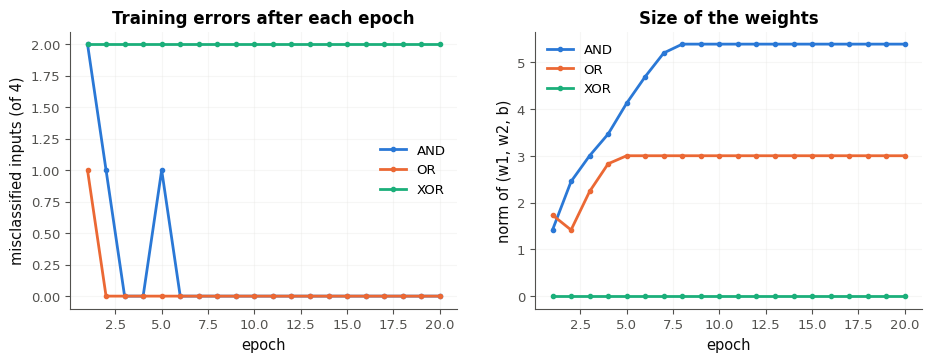

In [21]:
if any(answer is ... or answer is None for answer in [converges_13, xor_accuracy_13, xor_weights_13]):
    print("⏳ Ex 10.13 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    history_13 = {}
    for name_13 in ("and", "or", "xor"):
        X_13, y_13 = GATES[name_13]
        model_13 = SklearnPerceptron(shuffle=False, tol=None)          # each partial_fit call = one more epoch
        errors_13, norms_13, weights_13 = [], [], []
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for epoch_13 in range(20):
                model_13.partial_fit(X_13, y_13, classes=np.array([0, 1]))
                errors_13.append(int(np.sum(model_13.predict(X_13) != y_13)))
                weights_13.append(np.r_[model_13.coef_[0], model_13.intercept_])
                norms_13.append(float(np.linalg.norm(weights_13[-1])))
        history_13[name_13] = (errors_13, norms_13, weights_13)
        print(f"{name_13.upper():4s} errors after epochs 1 to 10: {errors_13[:10]} · accuracy after 20 epochs: "
              f"{model_13.score(X_13, y_13):.2f}")
    print("XOR, (w1, w2, b) after epochs 1 to 4:", [w.tolist() for w in history_13["xor"][2][:4]])
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for name_13, (errors_13, norms_13, _) in history_13.items():
        axes[0].plot(range(1, 21), errors_13, marker="o", ms=3, label=name_13.upper())
        axes[1].plot(range(1, 21), norms_13, marker="o", ms=3, label=name_13.upper())
    axes[0].set(xlabel="epoch", ylabel="misclassified inputs (of 4)", title="Training errors after each epoch")
    axes[1].set(xlabel="epoch", ylabel="norm of (w1, w2, b)", title="Size of the weights")
    for ax in axes:
        ax.legend()
        ax.grid(alpha=0.3)
    plt.show()

Dans tes notes : compare avec tes prédictions, puis explique chacun des trois résultats. Pour XOR, refais à la main une époque dans l'ordre (0, 0), (0, 1), (1, 0), (1, 1), à partir de poids nuls : que deviennent les poids, et qu'en déduis-tu pour l'accuracy ? Que fait la courbe d'AND autour de l'époque 5, et pourquoi ?

💡 AND et OR sont appris (0 erreur après quelques époques), XOR jamais : l'accuracy reste à 0,5 et les poids reviennent exactement à $(0, 0, 0)$ à la fin de **chaque** époque (B). Dans cet ordre, les quatre corrections d'une époque s'annulent : $-(0,0)$ et $b - 1$, puis $+(0,1)$ et $b + 1$, puis $+(1,0)$ et $b + 1$, puis $-(1,1)$ et $b - 1$. Avec des poids nuls, toutes les sommes valent 0 et le perceptron répond la classe 0 partout : 2 entrées justes sur 4. Dans d'autres ordres fixes, les poids reviennent aussi au même point à chaque époque (pas toujours zéro) ; avec un nouvel ordre tiré à chaque époque, ils errent parmi quelques valeurs, toujours bornées : c'est le théorème du cycle du perceptron (Block et Levin, 1970). La courbe d'AND remonte à 1 erreur à l'époque 5 après un passage à 0 : une entrée posée **sur** la frontière ($z = 0$) est bien prédite, mais la règle d'apprentissage la corrige quand même ($y z \le 0$), ce qui déplace la frontière ; tout rentre dans l'ordre à l'époque 6.

### Ex 10.14 — neuron_forward : un neurone appliqué à tout un lot 🔨 ★★ ⏱️ 15 min
**Objectif :** calculer la sortie d'un neurone pour tout un lot d'exemples en une opération matricielle.  
**Prérequis :** Ex 10.12 · 0A (produit matriciel @, broadcasting) · fiche §10.3.3 (encadré 🧮 sur les matrices) · **Fil rouge :** portes logiques · **mylearn :** `perceptron.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/perceptron.py`, mêmes règles qu'en 10.12 (NumPy seulement). Enregistre, puis relance la cellule de vérification.

Écris `neuron_forward(X, w, b=0.0, activation=sign_step)` (lis sa docstring) :
- convertis `X` et `w` avec `np.asarray` ; lève une `ValueError` si le nombre de features de `X` (sa dernière dimension) diffère de `len(w)` ;
- calcule **toutes** les sommes pondérées d'un coup, `X @ w + b`, puis applique l'activation **une seule fois**, au tableau entier : pas de boucle sur les exemples ;
- un seul exemple, de forme `(n_features,)`, donne un tableau 0-d (`np.asarray(...)` transforme le scalaire NumPy que renvoie `@` en tableau).

La vérification essaie les exemples de la docstring, le neurone AND de la fiche sur les quatre entrées, un exemple seul, compare les sommes avec `torch.nn.functional.linear`, puis lance les tests.

Dans tes notes : pourquoi appliquer l'activation une seule fois, au tableau entier ? Que renvoie `X @ w` quand `X` n'a qu'une dimension ?

In [22]:
if True:
    X_doc_14, w_doc_14 = np.array([[1.0, 2.0], [-1.0, 0.5]]), np.array([1.0, 1.0])
    out_14 = mylearn.perceptron.neuron_forward(X_doc_14, w_doc_14, b=-1.0)
    if returned("10.14", "neuron_forward", out_14):
        sums_14 = mylearn.perceptron.neuron_forward(X_doc_14, w_doc_14, b=-1.0, activation=lambda z: z)
        print("docstring examples:", np.asarray(out_14).tolist(), "and", np.asarray(sums_14).tolist())
        and_14 = mylearn.perceptron.neuron_forward(X_GATE, np.array([1.0, 1.0]), b=-1.5)
        print("the AND neuron of the course sheet on (0, 0), (0, 1), (1, 0), (1, 1):", np.asarray(and_14).tolist())
        verdict("10.14", np.array_equal(np.asarray(and_14, dtype=float).ravel(), [-1.0, -1.0, -1.0, 1.0]),
                "le neurone AND (w = (1, 1), b = −1,5) répond +1 pour (1, 1) seulement.",
                "attendu [-1, -1, -1, 1] pour le neurone AND : sign_step(X @ w + b), une sortie par ligne de X.")
        one_14 = mylearn.perceptron.neuron_forward(np.array([1.0, 2.0]), w_doc_14, b=-1.0, activation=lambda z: z)
        verdict("10.14", isinstance(one_14, np.ndarray) and one_14.ndim == 0 and float(one_14) == 2.0,
                "un seul exemple donne un tableau 0-d : array(2.).",
                f"un seul exemple doit donner un tableau 0-d, array(2.) ; reçu {one_14!r} (np.asarray(...) en fait un).")
        z_torch_14 = torch.nn.functional.linear(torch.tensor(X_doc_14), torch.tensor(w_doc_14)[None, :],
                                                torch.tensor([-1.0], dtype=torch.float64))[:, 0].numpy()
        print("the same weighted sums with torch.nn.functional.linear:", z_torch_14.tolist())
    run_mylearn_tests(impl="ref", keyword="test_neuron_forward_")

docstring examples: [1.0, -1.0] and [2.0, -1.5]
the AND neuron of the course sheet on (0, 0), (0, 1), (1, 0), (1, 1): [-1.0, -1.0, -1.0, 1.0]
✅ Ex 10.14 : le neurone AND (w = (1, 1), b = −1,5) répond +1 pour (1, 1) seulement.
✅ Ex 10.14 : un seul exemple donne un tableau 0-d : array(2.).
the same weighted sums with torch.nn.functional.linear: [2.0, -1.5]


pytest: 18 passed, 55 deselected in 1.94s


💡 La référence vérifie les formes, puis renvoie `np.asarray(activation(X @ w + b), dtype=float)`. Un appel unique de l'activation sur le vecteur des sommes est plus rapide (NumPy travaille en C sur tout le tableau) et c'est ce qu'attend une activation vectorisée : les bibliothèques de deep learning appliquent toujours leurs activations à des tableaux entiers. Avec `X` à une dimension, `X @ w` est un produit scalaire : un scalaire NumPy (`np.float64`), que `np.asarray` transforme en tableau 0-d, comme le promet la docstring. `torch.nn.functional.linear(X, W, b)` calcule `X @ W.T + b` : avec `W = w[None, :]`, une matrice d'une seule ligne, c'est exactement notre neurone.

### Ex 10.15 — Des noms de poids (AD, BE…) à la matrice W 🔨 ★★ ⏱️ 20 min
**Objectif :** traduire les poids nommés d'un schéma en matrice, calculer une couche entière, et passer à la convention de PyTorch.  
**Prérequis :** Ex 10.14 · Ex 10.5 · fiche §10.3.3 (convention AD, encadré 🧮 sur les matrices, encadré 🕰️ sur les conventions) · **Parcours :** C, M

Une couche de trois neurones D, E et F reçoit les sorties de trois neurones A, B et C, comme sur la figure 10.8 du livre ; les poids (de notre invention) sont dans le dictionnaire `WEIGHTS_15`, nommés dans la convention du livre (`"AD"` : de A vers D), et les biais de D, E, F dans `BIASES_15`. `X_15` contient les sorties de A, B, C pour quatre exemples (une ligne par exemple).

Écris :
- `names_to_matrix_15(weights, sources, targets)` : la matrice $\mathbf{W}$ de forme `(len(sources), len(targets))`, avec `W[j, k] = weights[sources[j] + targets[k]]` (la convention de mylearn : une ligne par source, une colonne par neurone) ;
- `layer_forward_15(X, W, b, activation=lambda z: z)` : `activation(X @ W + b)`, les sorties des trois neurones pour tout le lot.

La vérification contrôle :
a) $\mathbf{W}$, pour les sources `"ABC"` et les cibles `"DEF"` ;
b) les sorties de la couche, avec l'identité comme activation ;
puis les compare à celles de `torch.nn.Linear(3, 3)`, dont on copie les poids, et à ton `neuron_forward` (10.14) appliqué à chaque colonne de $\mathbf{W}$.
c) `pytorch_error_15` : si l'on copie $\mathbf{W}$ **tel quel** dans le `weight` de `nn.Linear(3, 3)`, sans le transposer, PyTorch lève-t-il une erreur ? (`True` ou `False`)

Dans tes notes : pourquoi la copie dans PyTorch demande-t-elle `W.T` ? Pourquoi l'erreur de c) est-elle si dangereuse ici, et le serait-elle moins avec une couche de 3 entrées et 2 neurones ?

In [23]:
# A layer of three neurons D, E, F fed by three neurons A, B, C (the network of figure 10.8 of the book, with
# weights of our own). A weight is named source first, destination second: AD multiplies the output of A for D.
WEIGHTS_15 = {"AD": 0.5, "AE": -1.0, "AF": 2.0,
              "BD": 1.5, "BE": 0.25, "BF": -0.5,
              "CD": -2.0, "CE": 1.0, "CF": 0.75}
BIASES_15 = np.array([0.1, -0.2, 0.0])                       # the biases of D, E and F
X_15 = np.array([[1.0, 0.0, 2.0], [0.5, -1.0, 1.0], [2.0, 1.0, 0.0], [0.0, 0.0, 0.0]])   # A, B, C for 4 samples

In [24]:
def names_to_matrix_15(weights, sources, targets):
    """Matrix W of shape (len(sources), len(targets)): W[j, k] is the weight named sources[j] + targets[k]."""
    return np.array([[weights[source + target] for target in targets] for source in sources], dtype=float)


def layer_forward_15(X, W, b, activation=lambda z: z):
    """Outputs of a whole layer for a batch: activation(X @ W + b), of shape (n_samples, n_neurons)."""
    return activation(np.asarray(X, dtype=float) @ np.asarray(W, dtype=float) + np.asarray(b, dtype=float))


pytorch_error_15 = False     # W and W.T have the same shape (3, 3): nothing tells PyTorch the copy is wrong

print_answer("10.15c", pytorch_error_15)
if True:
    W_15 = names_to_matrix_15(WEIGHTS_15, "ABC", "DEF")
    if returned("10.15", "names_to_matrix_15", W_15):
        W_15 = np.asarray(W_15, dtype=float)
        print("W (rows A, B, C; columns D, E, F):\n", W_15)
        print_answer("10.15a", W_15, computed=True)
        Z_15 = layer_forward_15(X_15, W_15, BIASES_15)
        if W_15.shape == (3, 3) and returned("10.15", "layer_forward_15", Z_15):
            Z_15 = np.asarray(Z_15, dtype=float)
            print("Z = X @ W + b (one row per sample, one column per neuron D, E, F):\n", Z_15.round(4))
            print_answer("10.15b", Z_15, computed=True)
            linear_15 = torch.nn.Linear(3, 3).double()
            with torch.no_grad():
                linear_15.weight.copy_(torch.tensor(W_15.T))        # PyTorch: one row per neuron, hence the transpose
                linear_15.bias.copy_(torch.tensor(BIASES_15))
                torch_15 = linear_15(torch.tensor(X_15)).numpy()
                linear_15.weight.copy_(torch.tensor(W_15))          # the classic mistake: W copied as it is
                wrong_15 = linear_15(torch.tensor(X_15)).numpy()
            verdict("10.15", Z_15.shape == (4, 3) and np.allclose(Z_15, torch_15),
                    "nn.Linear de PyTorch, avec weight = W.T, donne les mêmes sorties que X @ W + b.",
                    "nn.Linear (avec weight = W.T) ne donne pas tes sorties : vérifie W[j, k] = poids de sources[j] vers "
                    "targets[k], et X @ W + b.")
            print("W copied without the transpose: no error, but the first row becomes", wrong_15[0].round(4).tolist(),
                  "instead of", torch_15[0].round(4).tolist())
            tanh_15 = layer_forward_15(X_15, W_15, BIASES_15, activation=np.tanh)
            if returned("10.15", "layer_forward_15", tanh_15):
                tanh_15 = np.asarray(tanh_15, dtype=float)
                verdict("10.15", tanh_15.shape == Z_15.shape and np.allclose(tanh_15, np.tanh(Z_15)),
                        "avec activation=np.tanh, la couche applique tanh à chaque somme pondérée.",
                        "avec activation=np.tanh, attendu np.tanh(X @ W + b) : applique l'activation reçue en argument.")
            try:
                columns_15 = [mylearn.perceptron.neuron_forward(X_15, W_15[:, k], BIASES_15[k], activation=lambda z: z)
                              for k in range(3)]
            except NotImplementedError:
                print("⏳ la comparaison avec ton neuron_forward (10.14) s'affichera quand tu l'auras écrit.")
            else:
                verdict("10.15", np.allclose(np.column_stack(columns_15), Z_15),
                        "la colonne k de Z est la sortie du neurone k seul : neuron_forward(X, W[:, k], b[k]).",
                        "la colonne k de Z devrait être neuron_forward(X, W[:, k], b[k]) : relis la convention W[j, k].")

10.15c: False
W (rows A, B, C; columns D, E, F):
 [[ 0.5  -1.    2.  ]
 [ 1.5   0.25 -0.5 ]
 [-2.    1.    0.75]]
10.15a: [[0.5, -1.0, 2.0], [1.5, 0.25, -0.5], [-2.0, 1.0, 0.75]]
Z = X @ W + b (one row per sample, one column per neuron D, E, F):
 [[-3.4   0.8   3.5 ]
 [-3.15  0.05  2.25]
 [ 2.6  -1.95  3.5 ]
 [ 0.1  -0.2   0.  ]]
10.15b: [[-3.4, 0.8, 3.5], [-3.15, 0.05, 2.25], [2.6, -1.95, 3.5], [0.1, -0.2, 0.0]]
✅ Ex 10.15 : nn.Linear de PyTorch, avec weight = W.T, donne les mêmes sorties que X @ W + b.
W copied without the transpose: no error, but the first row becomes [4.6, 0.3, -0.5] instead of [-3.4, 0.8, 3.5]
✅ Ex 10.15 : avec activation=np.tanh, la couche applique tanh à chaque somme pondérée.
✅ Ex 10.15 : la colonne k de Z est la sortie du neurone k seul : neuron_forward(X, W[:, k], b[k]).


In [25]:
W_ref_15 = names_to_matrix_15(WEIGHTS_15, "ABC", "DEF")
wb.record("10.15a", W_ref_15, decimals=2, mistakes={"c'est la convention de PyTorch (une ligne par neurone) : mylearn met une ligne par source": W_ref_15.T})
wb.record("10.15b", X_15 @ W_ref_15 + BIASES_15, decimals=4, mistakes={"n'oublie pas d'ajouter le biais de chaque neurone": X_15 @ W_ref_15,
                                                                     "W est transposée : W[j, k] est le poids de la source j vers le neurone k": X_15 @ W_ref_15.T + BIASES_15})
wb.record("10.15c", pytorch_error_15, mistakes={"W et W.T ont la même forme (3, 3) : rien ne permet à PyTorch de voir l'erreur": True})

WB_ANSWER {"decimals": 2, "element_coarse": [["dc3f65ba3cf521be5ec9e6c48770db9b0a11622c28225add0650e3cfea91ac9c"], ["b4e6009c98db6eda44b5d9d892ed2dc6396f8d0ff5a14563b2c4e1e9dbe6bc31"], ["727c65900865bd2d2b3179f70624f0771d036d985fed5125f6f8f517724218e1"], ["15cc8c8f4a68f4250cbcbfebb22e4362f7c1e5c12bc478b68c572f2000dbf8c2"], ["4f7324f26a685e20b6ac8ba0b1f35816de5ce5cdaf84d1324c85f9a882c0ef95", "a2c27045531daef5a0d7fedb4b124cc1e5d044d12790c752b1d835c979995a3d"], ["3bbf6c8acca0271defd6b5508da8a48f223744e2fa10a1761c3b4087e76887c1"], ["159da4474afd1976b8d99804e065cd69606dc8658be2c68c39b10d4900c8b0e3"], ["416180fb481356a403385f260e977acf4f0e48d273900ef5c348d7bdfe69b856"], ["4d8c75fcb6173348cbd934bbd860494dd61c1b7fde63ea2ad30b5a9fd97f7ff3"]], "element_hashes": ["8325ec1cfa2c470f905b1f46e94b83bd656cb0f089bc54be550de91bf767cbed", "83abe79260ebc313dd6d469412e38ae4b1eaa02432651c8a02b35fdb1bba21d0", "9a89b6b03504152c9ab7e035aea8af22637af2d7235b09dac52225422a82200e", "f62b24a5a79115e2e0259ab78ebf13a4

💡 $\mathbf{W}$ a une ligne par source (A, B, C) et une colonne par neurone (D, E, F) : la colonne de D contient AD, BD, CD, les trois poids qui arrivent à D. PyTorch range une **ligne** par neurone (`weight` de forme `(out_features, in_features)`) et calcule `x @ weight.T + bias` : il faut donc lui donner `W.T`. Copier `W` sans transposer ne provoque **aucune** erreur ici, parce que la matrice est carrée : les sorties sont simplement fausses (la première ligne passe de $(-3{,}4;\ 0{,}8;\ 3{,}5)$ à $(4{,}6;\ 0{,}3;\ -0{,}5)$). Avec 3 entrées et 2 neurones, `W` aurait la forme $(3, 2)$ et PyTorch attendrait $(2, 3)$ : la copie échouerait, et l'erreur serait vue tout de suite. Une erreur de forme est une chance ; une erreur de convention sur une matrice carrée est silencieuse.

### Ex 10.16 — XOR avec trois neurones câblés à la main 🔨 ★★ ⏱️ 25 min
**Objectif :** construire un réseau de trois neurones qui calcule XOR, avec des sorties en ±1.  
**Prérequis :** Ex 10.5 · Ex 10.14 · fiche §10.3.2 · **Fil rouge :** portes logiques · **Parcours :** C

Avec **ton** `neuron_forward` (10.14, activation `sign_step` par défaut), écris `xor_network_16(X)` : deux neurones cachés reçoivent les deux entrées, un neurone de sortie reçoit les sorties des deux neurones cachés, et la fonction renvoie la sortie de ce dernier ($+1$ pour XOR = 1, $-1$ pour XOR = 0), pour tout un lot `X` de forme `(n, 2)`. Choisis les poids et les biais à la main ; ✏️ 10.5 te donne une piste, mais attention : avec `sign_step`, les neurones cachés sortent $-1$ ou $+1$, pas 0 ou 1. Vérifie que ton neurone de sortie en tient compte.

La vérification contrôle :
a) les sorties de ton réseau sur les quatre entrées $(0, 0)$, $(0, 1)$, $(1, 0)$, $(1, 1)$ ;
b) `n_params_16` : le nombre de poids et de biais de tes trois neurones ;
puis mesure l'accuracy de ton réseau sur 200 points bruités autour des quatre coins (`wb.synth.make_xor`, au moins 0,95 demandé), et dessine la région où il répond $+1$.

Dans tes notes : décris la région $+1$. Pourquoi des frontières à mi-chemin des coins résistent-elles mieux au bruit que des frontières qui frôlent les coins ? Les poids de sortie de ✏️ 10.5 marchent-ils encore avec des entrées en ±1, et pour quelle plage de biais ?

In [26]:
X_xor_16, y_xor_16 = wb.synth.make_xor(200, noise=0.15, seed=16)   # 200 noisy points around the four corners
t_xor_16 = np.where(y_xor_16 == 1, 1.0, -1.0)                             # XOR = 1 coded +1, XOR = 0 coded -1

10.16b: 9
outputs on (0, 0), (0, 1), (1, 0), (1, 1): [-1.0, 1.0, 1.0, -1.0]
10.16a: [-1.0, 1.0, 1.0, -1.0]
✅ Ex 10.16 : accuracy de 0,990 sur les 200 points bruités.


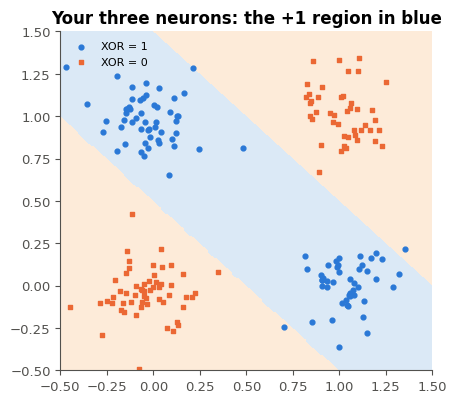

In [27]:
def xor_network_16(X):
    """XOR with three neurons, all with sign_step (outputs -1 or +1): two hidden neurons, then an output neuron."""
    h1 = mylearn.perceptron.neuron_forward(X, np.array([1.0, 1.0]), b=-0.5)      # OR: +1 unless both inputs are 0
    h2 = mylearn.perceptron.neuron_forward(X, np.array([-1.0, -1.0]), b=1.5)     # NAND: +1 unless both are 1
    hidden = np.column_stack([h1, h2])                                           # -1 or +1, not 0 or 1
    return mylearn.perceptron.neuron_forward(hidden, np.array([1.0, 1.0]), b=-1.0)   # +1 only if both are +1


n_params_16 = 9

print_answer("10.16b", n_params_16)
if True:
    corners_16 = xor_network_16(X_GATE)
    if returned("10.16", "xor_network_16", corners_16):
        corners_16 = np.asarray(corners_16, dtype=float).ravel()
        print("outputs on (0, 0), (0, 1), (1, 0), (1, 1):", corners_16.tolist())
        print_answer("10.16a", corners_16, computed=True)
        noisy_16 = np.asarray(xor_network_16(X_xor_16), dtype=float).ravel()
        accuracy_16 = float(np.mean(noisy_16 == t_xor_16)) if noisy_16.shape == t_xor_16.shape else 0.0
        verdict("10.16", accuracy_16 >= 0.95, f"accuracy de {fr(accuracy_16, 3)} sur les 200 points bruités.",
                f"accuracy de {fr(accuracy_16, 3)} sur les 200 points bruités : il faut au moins 0,95 (des frontières à "
                "mi-chemin des coins laissent de la marge au bruit).")
        grid_16 = np.linspace(-0.5, 1.5, 201)
        gx_16, gy_16 = np.meshgrid(grid_16, grid_16)
        regions_16 = np.asarray(xor_network_16(np.column_stack([gx_16.ravel(), gy_16.ravel()])), dtype=float)
        plt.figure(figsize=(4.8, 4.4))
        plt.contourf(gx_16, gy_16, regions_16.reshape(gx_16.shape), levels=[-2, 0, 2], colors=["#fdebd9", "#dbe9f6"])
        plt.scatter(*X_xor_16[y_xor_16 == 1].T, s=12, label="XOR = 1")
        plt.scatter(*X_xor_16[y_xor_16 == 0].T, s=12, marker="s", label="XOR = 0")
        plt.title("Your three neurons: the +1 region in blue")
        plt.legend(fontsize=8)
        plt.show()

In [28]:
wb.record("10.16a", [-1.0, 1.0, 1.0, -1.0], decimals=0, mistakes={"ce sont les sorties de XNOR : inverse le signe des poids et du biais du neurone de sortie": [1.0, -1.0, -1.0, 1.0],
                                                                    "les sorties demandées sont −1 et +1, pas 0 et 1 : le neurone de sortie passe par sign_step": [0.0, 1.0, 1.0, 0.0],
                                                                    "le neurone de sortie répond toujours −1 : avec des entrées en ±1, sa somme vaut −2, 0 ou 2 ; place son seuil entre 0 et 2": [-1.0, -1.0, -1.0, -1.0]})
wb.record("10.16b", n_params_16, mistakes={"n'oublie pas les biais : chaque neurone a le sien": 6})

WB_ANSWER {"decimals": 0, "element_hashes": ["0c1d3f98c3ecd896c4f5da34d990d876e94a7aa0081a70a47e156d1d60620199", "1fcf118949f134ed04457eba19cf9e30c578d98ecb4ff0cdb1a733200f604062", "dc382094aea6cd338250beef2becea57021e6b452647502e524bbe7763adcf30", "d2b224c93b2fdd955002db5861b1417cfba13f0a290119a32cebe5f01e658d9a"], "hash": "c4892beb24feccc621e03c76ad07ef2b554aefdb571826b9c9c24f58c624b4ae", "id": "10.16a", "integer": true, "kind": "array", "mistakes": {"2a91828045190c80db6d5618ba2ecaf56bcb8adca9a67a2d34ca8c779c7838a3": "le neurone de sortie répond toujours −1 : avec des entrées en ±1, sa somme vaut −2, 0 ou 2 ; place son seuil entre 0 et 2", "3e4318e109e6f99632fed34043dbb5a9e45920860ffdabcfb0908937dc6aa8f5": "les sorties demandées sont −1 et +1, pas 0 et 1 : le neurone de sortie passe par sign_step", "b5c45cc92f3f190ae127ae9e53fbb9d459aa739c137e48baf479f42bd91b70b7": "ce sont les sorties de XNOR : inverse le signe des poids et du biais du neurone de sortie"}, "shape": [4]}
📝 Ex 10.16a 

💡 La région $+1$ est une **bande** entre deux droites parallèles, $x_1 + x_2 = 0{,}5$ et $x_1 + x_2 = 1{,}5$ : le premier neurone caché (OR) répond $+1$ au-dessus de la première, le second (NAND) sous la seconde, et le neurone de sortie ne répond $+1$ que si les deux sont d'accord. Avec des frontières à mi-chemin, la somme $x_1 + x_2$ d'un coin est à 0,5 de la frontière la plus proche, soit plus de deux écarts-types du bruit de cette somme ($0{,}15\sqrt{2} \approx 0{,}21$) : l'accuracy vaut 0,99. Avec des entrées $h_1, h_2 \in \{-1, +1\}$, la somme $h_1 + h_2$ du neurone de sortie vaut $-2$, 0 ou 2 : tout biais $b$ strictement entre $-2$ et 0 donne AND. Le $-1{,}5$ de ✏️ 10.5 marche donc encore ; $-1$ est au milieu de la plage, la marge la plus sûre.

## Partie B · Apprendre : scikit-learn, courbes d'erreurs, puis ta classe Perceptron

Le perceptron apprend ses poids. Tu l'observes d'abord avec scikit-learn (le learning rate, la standardisation, les erreurs par époque), tu mets en forme la documentation de ta librairie, puis tu écris ta propre classe `Perceptron`. La cellule suivante prépare les manchots Adélie et Chinstrap du découpage du ch. 1, standardisés avec les manchots d'entraînement de ces deux espèces.

In [29]:
# Adelie against Chinstrap: the training and test penguins of ch. 1 of these two species, standardised with the
# mean and the standard deviation of the training ones (used in 10.17, 10.18, 10.21 and 10.22)
pair_17 = np.isin(species, ["Adelie", "Chinstrap"])
train_17, test_17 = TRAIN_CH1[pair_17[TRAIN_CH1]], TEST_CH1[pair_17[TEST_CH1]]
mean_17, std_17 = X_peng[train_17].mean(axis=0), X_peng[train_17].std(axis=0)
Z_train_17, Z_test_17 = (X_peng[train_17] - mean_17) / std_17, (X_peng[test_17] - mean_17) / std_17
y_train_17, y_test_17 = species[train_17], species[test_17]
print(f"Adelie against Chinstrap: {len(train_17)} training and {len(test_17)} test penguins")

Adelie against Chinstrap: 155 training and 59 test penguins


### Ex 10.17 — Le learning rate change-t-il un perceptron qui part de zéro ? 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir l'effet du learning rate sur un perceptron, selon qu'il part de zéro ou de poids aléatoires.  
**Prérequis :** Ex 10.6 · fiche §10.3.1 (encadré 🧮 sur la règle d'apprentissage) · **Fil rouge :** Penguins · **Parcours :** C, M

Le `Perceptron` de scikit-learn a un learning rate `eta0` ($\eta$ dans la fiche, 1 par défaut). On l'entraîne 50 époques, exemples dans l'ordre et sans critère d'arrêt (`tol=None`), à séparer les Adélie des Chinstrap (quatre mesures standardisées), avec `eta0` = 0,01, 1 et 100 ; une première fois en partant de poids nuls, une seconde fois en partant des **mêmes** poids aléatoires pour les trois (`coef_init`, `intercept_init`).

Prédis, **avant** d'exécuter quoi que ce soit :
a) `same_predictions_17` : en partant de zéro, les trois learning rates donnent-ils exactement les mêmes prédictions sur les manchots de test ? (`True` ou `False`)
b) `ratio_17` : en partant de zéro, par combien les poids appris avec `eta0 = 100` sont-ils multipliés par rapport à ceux appris avec `eta0 = 1` ? (un nombre)
c) `still_100_times_17` : en partant des mêmes poids aléatoires, les poids appris avec `eta0 = 100` valent-ils encore exactement 100 fois ceux appris avec `eta0 = 1` ? (`True` ou `False`)

Puis exécute l'expérience.

In [30]:
start_rng_17 = np.random.default_rng(17)                   # a random start for the second experiment
COEF_START_17, INTERCEPT_START_17 = start_rng_17.normal(size=(1, 4)) * 3, start_rng_17.normal(size=1)

In [31]:
same_predictions_17, ratio_17, still_100_times_17 = True, 100, False   # the answers, for the record

In [32]:
if any(answer is ... or answer is None for answer in [same_predictions_17, ratio_17, still_100_times_17]):
    print("⏳ Ex 10.17 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    rows_17, predictions_17 = [], {}
    for start_17 in ("zero", "random"):
        for eta_17 in (0.01, 1.0, 100.0):
            model_17 = SklearnPerceptron(eta0=eta_17, max_iter=50, shuffle=False, tol=None)
            init_17 = {} if start_17 == "zero" else {"coef_init": COEF_START_17.copy(), "intercept_init": INTERCEPT_START_17.copy()}
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model_17.fit(Z_train_17, y_train_17, **init_17)
            predictions_17[(start_17, eta_17)] = model_17.predict(Z_test_17)
            rows_17.append((start_17, eta_17, model_17.coef_[0].copy(), model_17.score(Z_train_17, y_train_17),
                            model_17.score(Z_test_17, y_test_17)))
    for start_17, eta_17, coef_17, train_acc_17, test_acc_17 in rows_17:
        print(f"start {start_17:6s} eta0 = {eta_17:<6g}: coef_ = {np.round(coef_17, 3)} · training {train_acc_17:.3f} · "
              f"test {test_acc_17:.3f}")
    print("zero start: coef_ for eta0 = 100 divided by coef_ for eta0 = 1:", np.round(rows_17[2][2] / rows_17[1][2], 6))
    print("random start: coef_ for eta0 = 100 divided by coef_ for eta0 = 1:", np.round(rows_17[5][2] / rows_17[4][2], 3))
    for start_17 in ("zero", "random"):
        same_17 = all(np.array_equal(predictions_17[(start_17, eta)], predictions_17[(start_17, 1.0)]) for eta in (0.01, 100.0))
        print(f"{start_17} start: the three learning rates give the same test predictions: {same_17}")

start zero   eta0 = 0.01  : coef_ = [ 0.113 -0.03  -0.001 -0.032] · training 1.000 · test 0.983
start zero   eta0 = 1     : coef_ = [11.346 -3.038 -0.056 -3.208] · training 1.000 · test 0.983
start zero   eta0 = 100   : coef_ = [1134.646 -303.755   -5.629 -320.783] · training 1.000 · test 0.983
start random eta0 = 0.01  : coef_ = [ 4.553  0.113 -0.229 -1.966] · training 0.987 · test 0.966
start random eta0 = 1     : coef_ = [11.383 -3.239 -0.507 -2.586] · training 1.000 · test 0.983
start random eta0 = 100   : coef_ = [ 809.069 -152.199  -56.182 -200.554] · training 1.000 · test 0.983
zero start: coef_ for eta0 = 100 divided by coef_ for eta0 = 1: [100. 100. 100. 100.]
random start: coef_ for eta0 = 100 divided by coef_ for eta0 = 1: [ 71.079  46.991 110.806  77.547]
zero start: the three learning rates give the same test predictions: True
random start: the three learning rates give the same test predictions: False


Dans tes notes : compare avec tes prédictions, puis explique chacun des trois résultats avec la règle de la fiche, en suivant ce que devient une correction quand $\eta$ change. Le learning rate d'une descente de gradient sur une loss (ch. 5) joue-t-il le même rôle ?

💡 Partis de zéro, les trois perceptrons ont des poids exactement proportionnels à `eta0` (rapport 100, à l'arrondi près) et font les mêmes prédictions : chaque correction est multipliée par $\eta$, toutes les sommes $z$ aussi, donc leurs signes, les erreurs et la suite des corrections ne changent pas. Partis des mêmes poids aléatoires, le départ, lui, ne change pas avec $\eta$ : le rapport des poids n'est plus 100 (il va de 47 à 111 selon la composante), et le rapport entre la taille des corrections et celle du départ change tout. Avec `eta0 = 0,01`, le départ pèse lourd et le perceptron reste près de lui (accuracy d'entraînement 0,987, test 0,966) ; avec `eta0 = 100`, le départ est vite noyé, et le résultat ressemble à celui d'un départ à zéro (1,000 et 0,983). Ici, `tol=None` compte aussi : avec le `tol` par défaut (0,001), scikit-learn s'arrête quand sa perte ne baisse plus d'au moins `tol` pendant 5 époques, et cette perte grandit avec $\eta$ ; `eta0 = 0,01` s'arrête alors après 6 époques, avec d'autres poids. En descente de gradient sur une loss (ch. 5, 19), le learning rate change la trajectoire et la convergence elle-même : trop petit, on avance à peine ; trop grand, on diverge. Le perceptron parti de zéro, qui ne regarde que des signes, est une exception.

### Ex 10.18 — Le perceptron de scikit-learn sur portes logiques et manchots 📦 ★★ ⏱️ 20 min
**Objectif :** entraîner le perceptron de scikit-learn, lire ses attributs, et voir l'effet de la standardisation.  
**Prérequis :** Ex 10.13 · ch. 8 (découpage du ch. 1) · fiche §10.3.1 et l'encadré 🧮 sur la règle · **Fil rouge :** Penguins · **Parcours :** R, C

`SklearnPerceptron(max_iter=100, shuffle=False, tol=None)` applique exactement la règle de la fiche : départ à zéro, $\eta = 1$, exemples dans l'ordre, 100 époques (`tol=None` désactive le critère d'arrêt de scikit-learn, fondé sur la loss d'entraînement ; l'early stopping sur un jeu de validation est un autre réglage, `early_stopping=True`, désactivé par défaut). Ses attributs : `coef_` (de forme `(1, n_features)` pour deux classes), `intercept_`, `n_iter_` ; sa méthode `score` donne l'accuracy.

a) `or_params_18` : la liste `[w1, w2, b]` apprise sur OR (`GATES["or"]`).
b) `xor_accuracy_18` : l'accuracy d'entraînement sur XOR.
c) `or_n_iter_18` : l'attribut `n_iter_` du modèle de a).
d) `raw_accuracy_18` : entraîné sur les quatre mesures **brutes** des manchots d'entraînement Adélie et Chinstrap (`X_peng[train_17]`, `y_train_17`), l'accuracy sur leurs manchots de test (`X_peng[test_17]`, `y_test_17`).
e) `std_accuracy_18` : la même chose avec les mesures standardisées (`Z_train_17`, `Z_test_17`).

Dans tes notes : que vaut vraiment `n_iter_` avec `tol=None`, et en quelle époque le perceptron a-t-il en fait convergé sur OR (✏️ 10.6) ? Pourquoi les mesures brutes donnent-elles un si mauvais perceptron ? Regarde `coef_` et `intercept_` : de combien le biais bouge-t-il à chaque correction, et de combien les poids de la masse, en grammes ?

In [33]:
def sk_fit_18(X, y):
    """scikit-learn's perceptron with the rule of the course sheet: samples in order, 100 epochs."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SklearnPerceptron(max_iter=100, shuffle=False, tol=None).fit(X, y)


or_model_18 = sk_fit_18(*GATES["or"])
or_params_18 = [*or_model_18.coef_[0].tolist(), float(or_model_18.intercept_[0])]
xor_accuracy_18 = sk_fit_18(*GATES["xor"]).score(*GATES["xor"])
or_n_iter_18 = or_model_18.n_iter_
raw_model_18 = sk_fit_18(X_peng[train_17], y_train_17)
raw_accuracy_18 = raw_model_18.score(X_peng[test_17], y_test_17)
std_accuracy_18 = sk_fit_18(Z_train_17, y_train_17).score(Z_test_17, y_test_17)
print("a)", or_params_18, "· b)", xor_accuracy_18, "· c)", or_n_iter_18, "· d)", round(raw_accuracy_18, 4),
      "· e)", round(std_accuracy_18, 4))
print("raw measurements: coef_ =", raw_model_18.coef_[0].round(1), "· intercept_ =", raw_model_18.intercept_[0])

a) [2.0, 2.0, -1.0] · b) 0.5 · c) 100 · d) 0.678 · e) 0.9831
raw measurements: coef_ = [30585.2 -1801.1 -1561.   -650. ] · intercept_ = -124.0


In [34]:
wb.record("10.18a", or_params_18, decimals=1, mistakes={"le biais vient en dernier dans la liste demandée": [-1.0, 2.0, 2.0]})
wb.record("10.18b", xor_accuracy_18, decimals=2, mistakes={"sur XOR, les poids reviennent à zéro : le perceptron répond la même classe partout": 0.75})
wb.record("10.18c", or_n_iter_18, mistakes={"6, c'est l'époque où le perceptron a convergé (✏️ 10.6) ; relis ce que compte n_iter_ avec tol=None": 6})
wb.record("10.18d", raw_accuracy_18, decimals=3, mistakes={"c'est l'accuracy avec les mesures standardisées (question e)": std_accuracy_18})
wb.record("10.18e", std_accuracy_18, decimals=3, mistakes={"c'est l'accuracy avec les mesures brutes (question d)": raw_accuracy_18})

WB_ANSWER {"decimals": 1, "element_hashes": ["a91faf38e550c441e566be25347ffc7fccaf6e30e7ff4f287cb75c8b0d79dcff", "c03c77bce1ba85cda9929d5f5e923f45f0cb1f17af3ae6ece1fb7c8c197bc81c", "1f7982795e54a2dbe8feb4f2110f13e9a2704f30c6525ef96d925193db0b9da3"], "hash": "b44767d52820958ee7767a9e7459587f12923d370a0f36b80fc0fa591e10191d", "id": "10.18a", "kind": "array", "mistakes": {"1af46c0882e38712eb309e88295c7b7088a4ca14aa863886abe5d8233eebcaa3": "le biais vient en dernier dans la liste demandée"}, "shape": [3]}
📝 Ex 10.18a : réponse enregistrée (array, 1 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "e30d900edc05a3a97a9a914dc4f1cd61abe37a4f38615179dd5eb49faf18938f", "hash_coarse": "ee22c29756b7781dc833497256c8c68f68cd733461c88f5b1f7cf9aae2be9871", "id": "10.18b", "kind": "float", "magnitude": -1, "mistakes": {"ad19f82f5ff60b8b56d6b92fbba36797482ffa7a1db3229a4901a887300c8c05": "sur XOR, les poids reviennent à zéro : le perceptron répond la même classe partout"}, "sign": 1}
📝 Ex 10.18b : réponse

💡 Sur OR, scikit-learn trouve $\mathbf{w} = (2, 2)$ et $b = -1$, les poids de ✏️ 10.6, et `n_iter_` vaut 100 : avec `tol=None`, il fait toujours `max_iter` époques, même si plus rien ne bouge après la sixième. Sur XOR, l'accuracy reste à 0,5. Sur les manchots, les mesures brutes donnent 0,678 sur le test, les mesures standardisées 0,983. Avec les mesures brutes, une correction ajoute $\pm\mathbf{x}$ aux poids, des milliers pour la masse en grammes, mais seulement $\pm 1$ au biais : après 100 époques, le biais ne vaut que −124, alors que les sommes $\mathbf{w}\cdot\mathbf{x}$ se comptent en millions. La frontière reste collée à l'origine, loin des manchots. Standardiser met toutes les mesures, et le biais, à la même échelle : une règle à appliquer avant tout modèle entraîné par corrections ou par gradient, régularisé, ou fondé sur des distances (ch. 12).

### Ex 10.19 — Erreurs par époque : séparable ou pas ? 📈 ★★ ⏱️ 20 min
**Objectif :** lire des courbes d'erreurs par époque pour décider si des données sont linéairement séparables, et en voir les limites.  
**Prérequis :** Ex 10.18 · fiche §10.3.2 (encadré 🧮 sur la convergence) · **Fil rouge :** Penguins · **Parcours :** R, C

La cellule suivante entraîne le perceptron de scikit-learn (exemples dans l'ordre) sur cinq jeux de données, trace après chaque époque le nombre d'exemples d'entraînement mal classés, et montre à droite le nuage de points de E : (A) AND ; (B) XOR ; (C) Adélie contre Gentoo, épaisseur du bec et longueur de la nageoire ; (D) Adélie contre Chinstrap, les quatre mesures ; (E) Adélie contre Chinstrap, longueur et épaisseur du bec. Pour les manchots, toutes les mesures sont standardisées, et l'on prend tous les manchots des deux espèces (il ne s'agit pas de prédire, mais de savoir si une droite les sépare). Lis les deux graphiques de courbes et le nuage de points, puis réponds :

a) `separable_19` : les lettres des courbes qui atteignent 0 et y restent à la fin, par ordre alphabétique (par exemple `"BE"`).
b) `zero_D_19` : la courbe D atteint-elle 0 `"A"` avant l'époque 5, `"B"` entre l'époque 5 et l'époque 50, ou `"C"` après l'époque 50 ?
c) `xor_errors_19` : combien d'entrées XOR sont mal classées après chaque époque ? (un seul nombre)
d) `stays_at_zero_19` : vrai ou faux, une courbe qui a touché 0 y reste toujours ensuite ?
e) `more_epochs_E_19` : vrai ou faux, avec dix fois plus d'époques, la courbe E finirait par atteindre 0 ?
f) `proof_19` : vrai ou faux, une courbe qui n'a pas atteint 0 après 300 époques prouve que les données ne sont pas linéairement séparables ?

Dans tes notes : comment expliques-tu d) ? Pourquoi les quatre mesures séparent-elles les Adélie des Chinstrap, et pas les deux mesures du bec seules ? Que te faudrait-il pour **prouver** qu'un jeu de données n'est pas linéairement séparable ?

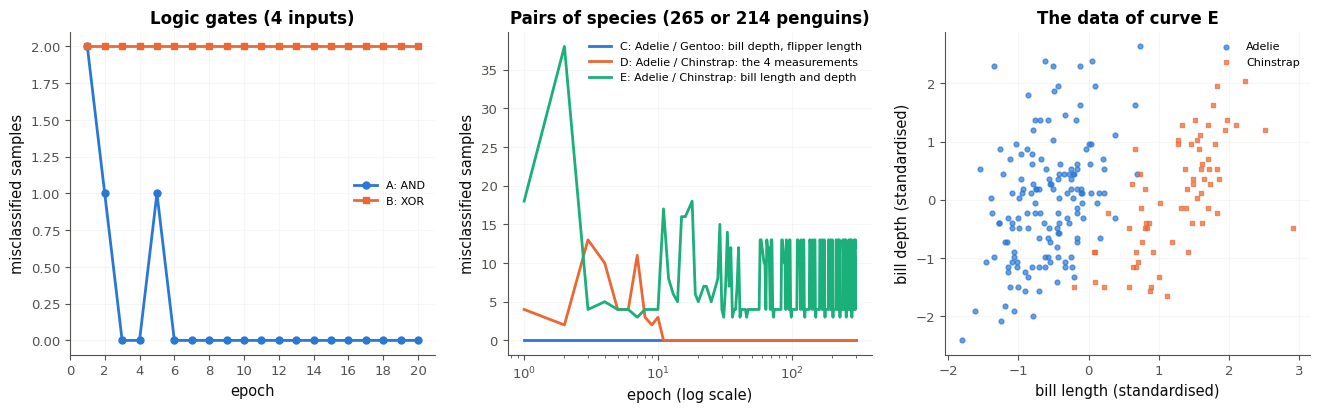

In [35]:
def errors_per_epoch_19(X, y, epochs):
    """Misclassified training samples after each epoch of scikit-learn's perceptron (samples in order)."""
    model = SklearnPerceptron(shuffle=False, tol=None)              # each partial_fit call = one more epoch
    classes = np.unique(y)
    errors = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for _ in range(epochs):
            model.partial_fit(X, y, classes=classes)
            errors.append(int(np.sum(model.predict(X) != y)))
    return errors


def penguin_pair_19(a, b, columns):
    """All the penguins of species a and b (no split here), the chosen columns standardised, and their species."""
    rows = np.isin(species, [a, b])
    X = X_peng[rows][:, columns]
    return (X - X.mean(axis=0)) / X.std(axis=0), species[rows]


DATASETS_19 = {"A": ("AND", *GATES["and"]), "B": ("XOR", *GATES["xor"]),
               "C": ("Adelie / Gentoo: bill depth, flipper length", *penguin_pair_19("Adelie", "Gentoo", [1, 2])),
               "D": ("Adelie / Chinstrap: the 4 measurements", *penguin_pair_19("Adelie", "Chinstrap", [0, 1, 2, 3])),
               "E": ("Adelie / Chinstrap: bill length and depth", *penguin_pair_19("Adelie", "Chinstrap", [0, 1]))}
curves_19 = {key: errors_per_epoch_19(X, y, 20 if key in "AB" else 300) for key, (_, X, y) in DATASETS_19.items()}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for key, marker in zip("AB", "os"):
    axes[0].plot(range(1, 21), curves_19[key], marker=marker, ms=5, label=f"{key}: {DATASETS_19[key][0]}")
for key in "CDE":
    axes[1].plot(range(1, 301), curves_19[key], label=f"{key}: {DATASETS_19[key][0]}")
axes[0].set(xlabel="epoch", ylabel="misclassified samples", title="Logic gates (4 inputs)", xticks=range(0, 21, 2))
axes[1].set(xscale="log", xlabel="epoch (log scale)", ylabel="misclassified samples",
            title="Pairs of species (265 or 214 penguins)")
X_E_19, y_E_19 = DATASETS_19["E"][1:]
for name, marker in (("Adelie", "o"), ("Chinstrap", "s")):
    axes[2].scatter(*X_E_19[y_E_19 == name].T, s=12, marker=marker, alpha=0.7, label=name)
axes[2].set(xlabel="bill length (standardised)", ylabel="bill depth (standardised)", title="The data of curve E")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.show()

In [36]:
separable_19, zero_D_19, xor_errors_19 = "ACD", "B", 2              # the answers, read on the curves
stays_at_zero_19, more_epochs_E_19, proof_19 = False, False, False
print("first epoch at 0:", {key: next((i + 1 for i, e in enumerate(curve) if e == 0), None) for key, curve in curves_19.items()},
      "· A:", curves_19["A"][:8], "· E, minimum:", min(curves_19["E"]))

first epoch at 0: {'A': 3, 'B': None, 'C': 1, 'D': 11, 'E': None} · A: [2, 1, 0, 0, 1, 0, 0, 0] · E, minimum: 3


In [37]:
wb.record("10.19a", separable_19, mistakes={"la courbe A (AND) finit aussi à 0, même après un rebond": "CD",
                                              "la courbe E remonte toujours : elle ne reste jamais à 0": "ACDE",
                                              "la courbe D atteint 0 et y reste : suis-la jusqu'au bout, sur l'échelle logarithmique": "AC"})
wb.record("10.19b", zero_D_19, mistakes={"lis l'axe des époques en échelle logarithmique : entre deux graduations (1, 10, 100), les époques ne sont pas régulièrement espacées": "C"})
wb.record("10.19c", xor_errors_19, mistakes={"4, c'est le nombre de corrections par époque ; la courbe B compte les entrées mal classées à la fin de chaque époque": 4})
wb.record("10.19d", stays_at_zero_19, mistakes={"regarde la courbe A : elle passe à 0 à l'époque 3, puis remonte à l'époque 5": True})
wb.record("10.19e", more_epochs_E_19, mistakes={"regarde le nuage de points de E : des Adélie et des Chinstrap se mêlent, aucune droite ne les sépare, et la courbe ne peut pas atteindre 0": True})
wb.record("10.19f", proof_19, mistakes={"une marge minuscule peut demander un nombre énorme de corrections : une courbe qui ne descend pas à 0 ne prouve rien": True})

WB_ANSWER {"hash": "c24b2130c9c9d596de4bf2f144624b227fe3e08e0927b056c6b8c9e8a192ab28", "id": "10.19a", "kind": "str", "mistakes": {"095eadf2b8e92bc8d3d5dff25cc5fa7f7d2539cab3a95374de7c98d149c23cd4": "la courbe A (AND) finit aussi à 0, même après un rebond", "6b7e3aaaccbc90ce9e44eede68599614d00db3cd0f4b0f40ac245b9c312c1feb": "la courbe E remonte toujours : elle ne reste jamais à 0", "b79834a83aabfd6c4c6405faa59001d197a08046b0017e3a959f2d7f9bae9df9": "la courbe D atteint 0 et y reste : suis-la jusqu'au bout, sur l'échelle logarithmique"}}
📝 Ex 10.19a : réponse enregistrée (str).
WB_ANSWER {"hash": "1039478694d331b0cd97bb25e6c467afca532ec54d9b3f4dee53379797509b74", "id": "10.19b", "kind": "str", "mistakes": {"bbe9613c3a96b1d48fff9c7ec39f0682dc36334f36777b0c1c4dfd07fa834204": "lis l'axe des époques en échelle logarithmique : entre deux graduations (1, 10, 100), les époques ne sont pas régulièrement espacées"}}
📝 Ex 10.19b : réponse enregistrée (str).
WB_ANSWER {"hash": "c5460e5ca69917535e7

💡 A, C et D atteignent 0 et y restent : ces données sont linéairement séparables (C dès la première époque, D à l'époque 11). B (XOR) reste à 2 erreurs : les poids reviennent à zéro, et le perceptron répond la classe 0 partout. E oscille sans fin, entre 3 et 18 erreurs après les premières époques (38 à la 2ᵉ) : quelques Adélie et Chinstrap se mêlent dans le plan des deux mesures du bec (le nuage de droite), et la dernière correction peut toujours casser ce que les précédentes avaient réparé ; avec la masse et la nageoire en plus, une frontière existe dans l'espace à quatre dimensions. La courbe A rebondit (0, 0, puis 1) : une entrée posée exactement sur la frontière est bien prédite mais corrigée quand même, ce qui déplace la frontière. Une courbe qui n'atteint pas 0 ne prouve rien : la borne $(R/\gamma)^2$ peut être énorme si la marge est minuscule. Pour **prouver** qu'aucun hyperplan ne sépare les données, il faut un autre outil : un problème d'optimisation linéaire (*linear programming*) sans solution, ou un SVM à marge dure qui n'atteint pas 100 % sur l'entraînement (ch. 13). Le programme linéaire « trouver $\mathbf{w}$ et $b$ tels que $y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \ge 1$ pour tout $i$ » (`scipy.optimize.linprog`) confirme les courbes : il a une solution pour C et D, aucune pour E.

### Ex 10.20 — Docstring NumPy et doctest pour neuron_forward 🛠️ ★★ ⏱️ 20 min
**Objectif :** compléter la docstring d'une fonction de ta librairie avec des exemples exécutés par doctest, et les faire passer avec pytest.  
**Prérequis :** Ex 10.14 · 0A (docstrings au format NumPy, doctest, 0A.61) · fiche §10.3.3 · **Parcours :** C

La docstring de `neuron_forward`, dans ta copie `mon_travail/mylearn/perceptron.py`, suit le format NumPy : un résumé d'une ligne, une description, puis des sections soulignées de tirets (`Parameters`, `Returns`, `Raises`, `Notes`, `Examples`). Les lignes `>>>` de la section `Examples` ne sont pas décoratives : **doctest** les exécute et compare ce que Python affiche, caractère par caractère, à la ligne qui suit. Une docstring dont les exemples sont vérifiés ne peut pas mentir longtemps.

Ajoute, à la fin de la section `Examples` de **ta** `neuron_forward`, au moins deux exemples :
1. un seul exemple, `np.array([1.0, 2.0])`, avec les poids `w` et le biais `b=-1.0` des exemples existants et l'activation identité : la sortie doit être un tableau 0-d ;
2. l'astuce du biais : le lot `X` des exemples existants passé par `add_bias_column`, avec les poids `np.array([-1.0, 1.0, 1.0])` et le biais par défaut : la même sortie que le premier exemple.

Pour écrire la sortie attendue d'un exemple, **exécute-le** d'abord dans une cellule, puis recopie exactement ce que Python affiche (une phrase d'explication peut précéder un exemple, séparée par une ligne vide). Enregistre ton fichier : la vérification recharge ta librairie, contrôle les sections et tes nouveaux exemples, puis lance `pytest --doctest-modules` sur ton fichier, pour les exemples de `sign_step`, `add_bias_column` et `neuron_forward`. Dans un terminal : `python -m pytest --doctest-modules mon_travail/mylearn/perceptron.py` (après 10.21, l'exemple de la classe `Perceptron` passera aussi).

Dans tes notes : que verrait doctest si ta fonction renvoyait `np.float64(2.0)` au lieu de `array(2.)` ? Pourquoi l'exemple `clf.intercept_` de la docstring de `Perceptron` demande-t-il un `float` Python ? Pourquoi un exemple vérifié vaut-il mieux qu'un commentaire ?

In [38]:
def run_doctests(path, keyword):
    """Run with pytest the doctests of the module at `path` selected by `keyword`; print the failures."""
    command = [sys.executable, "-m", "pytest", "--doctest-modules", str(path), "-k", keyword, "-q",
               "-p", "no:cacheprovider", "--color=no", "-rf", "--tb=short"]
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True, env={**os.environ, "COLUMNS": "1000"})
    lines = result.stdout.strip().splitlines()
    if "NotImplementedError" in result.stdout:
        print("⏳ une de ces fonctions n'est pas encore écrite (10.12, 10.14) : ses exemples ne peuvent pas passer.")
    elif result.returncode not in (0, 5):                     # 5: no doctest collected
        print("\n".join(line for line in lines[:40] if line.strip()))
    print("pytest --doctest-modules:", lines[-1] if lines else result.stderr.strip()[-300:])
    return result.returncode == 0


def sections_of(docstring):
    """The NumPy sections of a docstring: a title on its own line, underlined with dashes."""
    return re.findall(r"^(\w[\w ]*)\n-{3,}$", docstring, flags=re.M)

In [39]:
if True:
    doc_20 = inspect.getdoc(mylearn.perceptron.neuron_forward) or ""
    sections_20 = sections_of(doc_20)
    examples_20 = doctest.DocTestParser().get_examples(doc_20)
    print(f"neuron_forward: sections {sections_20} · {len(examples_20)} examples (>>>)")
    if len(examples_20) <= 4:
        print("⏳ Ex 10.20 : ajoute tes deux exemples à la section Examples de neuron_forward, dans "
              "mon_travail/mylearn/perceptron.py, enregistre, puis relance cette cellule.")
    else:
        verdict("10.20", all(name in sections_20 for name in ("Parameters", "Returns", "Raises", "Examples")),
                "les sections Parameters, Returns, Raises et Examples sont là, soulignées.",
                "il manque une section soulignée (Parameters, Returns, Raises ou Examples) : garde le format NumPy.")
        verdict("10.20", any("add_bias_column(" in example.source for example in examples_20),
                "un exemple montre l'astuce du biais (add_bias_column).",
                "ajoute un exemple qui passe par add_bias_column (l'astuce du biais).")
        verdict("10.20", any(re.fullmatch(r"array\([^\[\]]*\)\n?", example.want) for example in examples_20),
                "un exemple montre la sortie d'un seul échantillon : un tableau 0-d, array(...).",
                "ajoute un exemple avec un seul échantillon : sa sortie s'affiche array(...), sans crochets.")
        passed_20 = run_doctests(Path(mylearn.perceptron.__file__), "sign_step or add_bias_column or neuron_forward")
        verdict("10.20", passed_20, "doctest : tous les exemples de sign_step, add_bias_column et neuron_forward passent.",
                "doctest : un exemple ne donne pas la sortie écrite (détail au-dessus). Exécute-le et recopie exactement ce "
                "que Python affiche, ou corrige ta fonction.")

neuron_forward: sections ['Parameters', 'Returns', 'Raises', 'Notes', 'Examples'] · 6 examples (>>>)
✅ Ex 10.20 : les sections Parameters, Returns, Raises et Examples sont là, soulignées.
✅ Ex 10.20 : un exemple montre l'astuce du biais (add_bias_column).
✅ Ex 10.20 : un exemple montre la sortie d'un seul échantillon : un tableau 0-d, array(...).


pytest --doctest-modules: 3 passed, 1 deselected in 0.13s
✅ Ex 10.20 : doctest : tous les exemples de sign_step, add_bias_column et neuron_forward passent.


💡 La référence ajoute exactement ces deux exemples (lis `solutions/mylearn_ref/perceptron.py` après avoir réussi) : `neuron_forward(np.array([1.0, 2.0]), w, b=-1.0, activation=lambda z: z)` affiche `array(2.)`, et `neuron_forward(add_bias_column(X), np.array([-1.0, 1.0, 1.0]))` affiche `array([ 1., -1.])`, comme le premier exemple. Doctest compare des **textes** : avec NumPy 2, un scalaire s'affiche `np.float64(2.0)`, pas `array(2.)`, et un `np.float64(-4.0)` ne s'affiche pas `-4.0` : l'exemple échouerait, et il signalerait une vraie différence de type, celle que promet la docstring. C'est la force des exemples vérifiés : ils documentent l'usage, et ils cassent dès que le code et la documentation divergent, alors qu'un commentaire faux le reste en silence.

### Ex 10.21 — La classe Perceptron et sa règle d'apprentissage 🔨 ★★★ ⏱️ 45 min
**Objectif :** programmer le perceptron de Rosenblatt avec la règle classique, et le vérifier contre scikit-learn.  
**Prérequis :** Ex 10.6 · Ex 10.12 · 0A (classes) · fiche §10.3.1 (encadré 🧮 sur la règle) et §10.3.2 · **Fil rouge :** portes logiques · **mylearn :** `perceptron.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/perceptron.py`, mêmes règles qu'en 10.12 (NumPy seulement). Enregistre, puis relance la cellule de vérification.

Écris la classe `Perceptron(eta0=1.0, max_iter=100, fit_intercept=True, shuffle=False, random_state=None)` (lis sa docstring ; `__init__` est déjà écrit) :
- `fit(X, y)` : lève une `ValueError` si `y` n'a pas exactement deux classes, si `eta0 <= 0`, si `max_iter < 1` ou si `len(X) != len(y)` ; range les classes triées dans `classes_` et code `classes_[0]` en $-1$, `classes_[1]` en $+1$ ; pars de poids et d'un biais **nuls** ; à chaque époque, parcours les exemples dans l'ordre (dans un ordre aléatoire tiré avec `rng = np.random.default_rng(random_state)`, créé dans `fit`, si `shuffle=True`) ; un exemple est une erreur si $y(\mathbf{w}\cdot\mathbf{x} + b) \le 0$, et alors $\mathbf{w} \leftarrow \mathbf{w} + \eta\,y\,\mathbf{x}$, $b \leftarrow b + \eta\,y$ (pas de biais si `fit_intercept=False`) ; compte les erreurs de chaque époque dans la liste `errors_` (des `int` Python) ; arrête-toi après une époque sans erreur ou après `max_iter` époques ; renvoie `self`, avec `coef_` (forme `(n_features,)`), `intercept_` (un `float` Python), `n_iter_` et `errors_` ;
- `decision_function(X)` : `X @ coef_ + intercept_` ;
- `predict(X)` : `classes_[1]` là où le score est $> 0$, `classes_[0]` ailleurs ;
- `score(X, y)` : l'accuracy.

La vérification essaie l'exemple de la docstring (AND), refait OR et compare à tes calculs à la main de ✏️ 10.6, montre XOR, compare tes poids à ceux de scikit-learn sur les manchots, trace tes erreurs par époque, puis lance les tests.

Dans tes notes : pourquoi coder les labels en $-1$ et $+1$ ? Pourquoi $\le 0$ et pas $< 0$ ? Pourquoi créer le générateur aléatoire dans `fit` et pas dans `__init__` ?

AND: coef_ [3.0, 2.0] · intercept_ -4.0 · errors_ [2, 3, 3, 2, 2, 3, 2, 1, 0]
✅ Ex 10.21 : AND : les poids, le biais et les erreurs par époque de la docstring.
OR: coef_ [2.0, 2.0] · intercept_ -1.0 · errors_ [3, 1, 2, 2, 1, 0]
✅ Ex 10.21 : OR : les erreurs par époque trouvées à la main en ✏️ 10.6, [3, 1, 2, 2, 1, 0].
XOR, max_iter=10: errors_ [4, 4, 4, 4, 4, 4, 4, 4, 4, 4] · coef_ [0.0, 0.0] · intercept_ 0.0
✅ Ex 10.21 : Adélie contre Chinstrap : les poids de scikit-learn, 11 époques, accuracy de test 0,983.


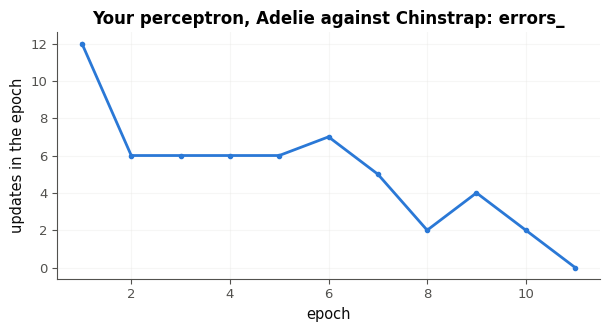

pytest: 36 passed, 37 deselected in 0.91s


In [40]:
if True:
    and_21 = fitted(mylearn.perceptron.Perceptron(), *GATES["and"])
    errors_and_21 = learned(and_21, "errors_")
    if errors_and_21 is not None:
        print("AND: coef_", np.asarray(and_21.coef_).tolist(), "· intercept_", and_21.intercept_, "· errors_", errors_and_21)
        verdict("10.21", list(errors_and_21) == [2, 3, 3, 2, 2, 3, 2, 1, 0] and np.allclose(and_21.coef_, [3.0, 2.0])
                and and_21.intercept_ == -4.0,
                "AND : les poids, le biais et les erreurs par époque de la docstring.",
                "AND : attendu coef_ = [3, 2], intercept_ = −4 et errors_ = [2, 3, 3, 2, 2, 3, 2, 1, 0] (docstring).")
    or_21 = fitted(mylearn.perceptron.Perceptron(), *GATES["or"])
    errors_or_21 = learned(or_21, "errors_")
    if errors_or_21 is not None:
        print("OR: coef_", np.asarray(or_21.coef_).tolist(), "· intercept_", or_21.intercept_, "· errors_", errors_or_21)
        verdict("10.21", list(errors_or_21) == [3, 1, 2, 2, 1, 0],
                "OR : les erreurs par époque trouvées à la main en ✏️ 10.6, [3, 1, 2, 2, 1, 0].",
                "OR : attendu errors_ = [3, 1, 2, 2, 1, 0], comme à la main en ✏️ 10.6.")
    xor_21 = fitted(mylearn.perceptron.Perceptron(max_iter=10), *GATES["xor"])
    if learned(xor_21, "errors_") is not None:
        print("XOR, max_iter=10: errors_", xor_21.errors_, "· coef_", np.asarray(xor_21.coef_).tolist(),
              "· intercept_", xor_21.intercept_)
    penguins_21 = fitted(mylearn.perceptron.Perceptron(max_iter=200), Z_train_17, y_train_17)
    oracle_21 = SklearnPerceptron(max_iter=200, shuffle=False, tol=None).fit(Z_train_17, y_train_17)
    if learned(penguins_21, "errors_") is not None:
        same_21 = (np.shape(penguins_21.coef_) == (4,) and np.allclose(penguins_21.coef_, oracle_21.coef_[0])
                   and np.isclose(penguins_21.intercept_, oracle_21.intercept_[0]))
        verdict("10.21", same_21,
                f"Adélie contre Chinstrap : les poids de scikit-learn, {penguins_21.n_iter_} époques, accuracy de test "
                f"{fr(penguins_21.score(Z_test_17, y_test_17), 3)}.",
                "Adélie contre Chinstrap : tes poids diffèrent de ceux de scikit-learn (shuffle=False, tol=None) : "
                "lis les tests ci-dessous.")
        plt.figure(figsize=(7, 3.2))
        plt.plot(range(1, len(penguins_21.errors_) + 1), penguins_21.errors_, marker="o", ms=3)
        plt.xlabel("epoch")
        plt.ylabel("updates in the epoch")
        plt.title("Your perceptron, Adelie against Chinstrap: errors_")
        plt.grid(alpha=0.3)
        plt.show()
    run_mylearn_tests(impl="ref", keyword="test_perceptron_")

💡 Dans la référence (`solutions/mylearn_ref/perceptron.py`, à lire **après** avoir réussi les tests), `fit` vérifie les entrées, code les labels avec `np.where(y == classes[1], 1.0, -1.0)`, puis enchaîne deux boucles : les époques, et les exemples d'une époque (`rng.permutation(n)` si `shuffle`). Les labels $\pm 1$ permettent une seule formule pour les deux classes : avec des labels 0 et 1, les exemples de la classe 0 ne corrigeraient rien (bug n° 2 de 10.22). Le test $\le 0$ compte une somme nulle comme une erreur : partis de zéro, toutes les sommes sont nulles, et un test $< 0$ laisserait les poids à zéro pour toujours. Le générateur créé dans `fit` garantit que deux appels de `fit` avec le même `random_state` donnent le même modèle. Sur les manchots Adélie et Chinstrap standardisés, tes poids sont exactement ceux de scikit-learn : sa classe `Perceptron` est une descente de gradient stochastique sur la perte $\max(0, -yz)$, qui fait les mêmes corrections, dans le même ordre.

## Partie C · Déboguer, mesurer, combiner, et le défi « Mark I »

Quatre bugs classiques à corriger (10.22), la borne de convergence mise à l'épreuve (10.23), trois espèces de manchots avec des perceptrons combinés (10.24), puis un défi sur des chiffres manuscrits lus par 400 photocellules, comme le Mark I (10.25). Les outils et les données des parties A et B restent disponibles.

### Ex 10.22 — Perceptron piégé : quatre bugs classiques 🐛 ★★★ ⏱️ 30 min
**Objectif :** trouver et corriger les erreurs classiques d'une implémentation du perceptron.  
**Prérequis :** Ex 10.21 · fiche §10.3.1 (encadré 🧮 sur la règle), §10.3.3 (le biais) · pièges ⚠️ de la fiche · **Fil rouge :** portes logiques · **Parcours :** C

Un collègue a écrit `BuggyPerceptron22`, ci-dessous. Il est content : « sur AND, il converge en une seule époque ! ». La cellule qui suit sa classe montre ce qu'il obtient. Quatre bugs s'y cachent : un test d'erreur trop strict, des labels mal codés, un biais qui n'apprend pas, un mélange qui désaligne les données (et modifie celles de l'appelant).

Écris `FixedPerceptron22`, une copie corrigée de sa méthode `fit` (les autres méthodes sont héritées). La vérification lance quatre diagnostics, un par bug, dans cet ordre : le test d'erreur, les labels, le biais, le mélange ; chacun suppose les précédents corrigés, et n'est lancé que s'ils passent. Elle compare enfin tes poids à ceux de scikit-learn sur les manchots.

Dans tes notes : pour chaque bug, la ligne fautive, le symptôme et la correction. Pourquoi le premier diagnostic que voit ton collègue (« converge en une époque ») est-il un piège ? Lequel des quatre bugs n'apparaît qu'avec `shuffle=True` ?

In [41]:
class BuggyPerceptron22:
    """A colleague's perceptron. It "converges in one epoch"... Four bugs hide in it."""

    def __init__(self, eta0=1.0, max_iter=100, shuffle=False, random_state=None):
        self.eta0, self.max_iter, self.shuffle, self.random_state = eta0, max_iter, shuffle, random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        rng = np.random.default_rng(self.random_state)
        self.coef_, self.intercept_, self.errors_ = np.zeros(X.shape[1]), 0.0, []
        for _ in range(self.max_iter):
            if self.shuffle:
                rng.shuffle(X)                                       # a new order at each epoch
            mistakes = 0
            for xi, yi in zip(X, y):
                if yi * (xi @ self.coef_ + self.intercept_) < 0:     # misclassified
                    self.coef_ = self.coef_ + self.eta0 * yi * xi
                    mistakes += 1
            self.errors_.append(mistakes)
            if mistakes == 0:
                break
        self.n_iter_ = len(self.errors_)
        return self

    def decision_function(self, X):
        return np.asarray(X, dtype=float) @ self.coef_ + self.intercept_

    def predict(self, X):
        return np.where(self.decision_function(X) > 0, self.classes_[1], self.classes_[0])


demo_22 = BuggyPerceptron22().fit(*GATES["and"])
print("the colleague's perceptron on AND: errors_ =", demo_22.errors_, "· coef_ =", demo_22.coef_.tolist(),
      "· accuracy =", np.mean(demo_22.predict(GATES["and"][0]) == GATES["and"][1]))

the colleague's perceptron on AND: errors_ = [0] · coef_ = [0.0, 0.0] · accuracy = 0.75


In [42]:
class FixedPerceptron22(BuggyPerceptron22):
    """The colleague's perceptron, corrected: copy its fit method here and fix the four bugs."""

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        target = np.where(y == self.classes_[1], 1.0, -1.0)            # bug 2: the labels must be -1 and +1
        rng = np.random.default_rng(self.random_state)
        self.coef_, self.intercept_, self.errors_ = np.zeros(X.shape[1]), 0.0, []
        for _ in range(self.max_iter):
            order = rng.permutation(len(X)) if self.shuffle else range(len(X))   # bug 4: shuffle indices, not X
            mistakes = 0
            for i in order:
                if target[i] * (X[i] @ self.coef_ + self.intercept_) <= 0:   # bug 1: a sum of 0 is a mistake
                    self.coef_ = self.coef_ + self.eta0 * target[i] * X[i]
                    self.intercept_ += self.eta0 * target[i]               # bug 3: the bias learns too
                    mistakes += 1
            self.errors_.append(mistakes)
            if mistakes == 0:
                break
        self.n_iter_ = len(self.errors_)
        return self

def strict_test_22():
    """1. From zero weights every sum is 0: the first sample must count as a mistake and move the weights."""
    model = fitted(FixedPerceptron22(max_iter=1), np.array([[1.0, 0.0], [-1.0, 0.0]]), np.array([1, -1]))
    if not np.any(np.asarray(model.coef_) != 0):
        return ("après une époque sur deux exemples, les poids sont encore nuls : au départ, toutes les sommes valent "
                "0 ; une somme nulle doit compter comme une erreur (y·z <= 0, pas < 0).")
    return ""


def labels_22():
    """2. Labels 0/1, -1/+1 or text give the same weights, on data separable through the origin."""
    X = np.array([[2.0, 1.0], [1.0, 2.0], [-1.0, -2.0], [-2.0, -1.0]])
    coefs = []
    for name, y in (("0 et 1", np.array([1, 1, 0, 0])), ("−1 et +1", np.array([1, 1, -1, -1])),
                    ("texte", np.array(["yes", "yes", "no", "no"]))):
        try:
            model = fitted(FixedPerceptron22(), X, y)
        except NotImplementedError:
            raise
        except Exception as error:
            return (f"avec les labels {name}, ton fit lève {type(error).__name__} ({error}) : code les labels en −1 et "
                    "+1 à partir de classes_.")
        if model.errors_[-1] != 0:
            return (f"avec les labels {name}, l'entraînement ne s'arrête pas sur des données séparables (errors_ finit "
                    f"par {model.errors_[-3:]}) : code classes_[0] en −1 et classes_[1] en +1 (avec les labels 0 et 1, "
                    "la classe 0 ne corrige rien).")
        if not np.array_equal(model.predict(X), y):
            return (f"avec les labels {name}, les prédictions ne redonnent pas les labels, sur des données séparables : "
                    "code les labels à partir de classes_ (classes_[0] en −1, classes_[1] en +1), pas en comparant y à 1.")
        coefs.append(np.asarray(model.coef_, dtype=float))
    if not all(np.allclose(coef, coefs[1]) for coef in coefs):
        return ("les labels 0/1, −1/+1 et texte ne donnent pas les mêmes poids : code classes_[0] en −1 et classes_[1] "
                "en +1.")
    return ""


def bias_22():
    """3. AND is learned, with a bias that is not zero (no line through the origin computes AND)."""
    X, y = GATES["and"]
    model = fitted(FixedPerceptron22(), X, y)
    if not (np.array_equal(model.predict(X), y) and model.intercept_ != 0 and model.errors_[-1] == 0):
        return (f"AND n'est pas appris (prédictions {np.asarray(model.predict(X)).tolist()}, intercept_ = "
                f"{model.intercept_}) : le biais doit être corrigé avec les poids (b += eta0 * y) ; sans biais, AND est "
                "impossible (✏️ 10.2 g).")
    return ""


def shuffle_22():
    """4. shuffle=True: the caller's X is untouched, the penguins are still learned, and the order changes."""
    in_order = np.asarray(fitted(FixedPerceptron22(), Z_train_17, y_train_17).coef_, dtype=float)
    changed = False
    for seed in range(5):
        X = Z_train_17.copy()
        model = fitted(FixedPerceptron22(shuffle=True, random_state=seed), X, y_train_17)
        if not np.array_equal(X, Z_train_17):
            return ("avec shuffle=True, ton fit modifie le tableau X de l'appelant : mélange l'ordre de visite (des "
                    "indices, rng.permutation(n)), pas les données.")
        if model.errors_[-1] != 0 or not np.array_equal(model.predict(Z_train_17), y_train_17):
            return (f"avec shuffle=True (graine {seed}), les manchots, séparables, ne sont plus appris (errors_ finit "
                    f"par {model.errors_[-3:]}) : les exemples ont perdu leurs labels ; parcours X[i] et y[i] ensemble, "
                    "dans l'ordre d'une permutation des indices.")
        changed = changed or not np.allclose(np.asarray(model.coef_, dtype=float), in_order)
    if not changed:
        return ("avec shuffle=True, les poids sont ceux de shuffle=False pour les graines 0 à 4 : l'ordre de visite ne "
                "change pas ; tire une permutation des indices à chaque époque.")
    return ""


DIAGNOSTICS_22 = [("le test d'erreur", strict_test_22, "une somme nulle compte comme une erreur : les poids quittent zéro."),
                  ("les labels", labels_22, "labels 0 et 1, −1 et +1 ou texte : les mêmes poids, et l'entraînement s'arrête."),
                  ("le biais", bias_22, "AND est appris, avec un biais non nul (AND est impossible sans biais)."),
                  ("le mélange", shuffle_22, "avec shuffle=True, X reste intact, les manchots sont appris et l'ordre "
                                             "de visite change d'une graine à l'autre.")]

if True:
    blocked_22 = None
    for number_22, (name_22, diagnostic_22, success_22) in enumerate(DIAGNOSTICS_22, start=1):
        if blocked_22 is not None:
            print(f"⏳ Ex 10.22 : {number_22}. {name_22} : corrige d'abord le point {blocked_22}.")
            continue
        try:
            problem_22 = diagnostic_22()
        except NotImplementedError:
            raise
        except Exception as error_22:                 # a crash of your fit: say which diagnostic it broke
            problem_22 = f"ton fit lève {type(error_22).__name__} ({error_22})."
        verdict("10.22", not problem_22, f"{number_22}. {success_22}", f"{number_22}. {problem_22}")
        if problem_22:
            blocked_22 = number_22
    if blocked_22 is None:
        oracle_22 = SklearnPerceptron(max_iter=100, shuffle=False, tol=None).fit(Z_train_17, y_train_17)
        model_22 = fitted(FixedPerceptron22(), Z_train_17, y_train_17)
        verdict("10.22", np.allclose(model_22.coef_, oracle_22.coef_[0]) and np.isclose(model_22.intercept_, oracle_22.intercept_[0]),
                "bilan : sur les manchots, les mêmes poids que scikit-learn.",
                "bilan : sur les manchots, tes poids diffèrent encore de ceux de scikit-learn.")

✅ Ex 10.22 : 1. une somme nulle compte comme une erreur : les poids quittent zéro.
✅ Ex 10.22 : 2. labels 0 et 1, −1 et +1 ou texte : les mêmes poids, et l'entraînement s'arrête.
✅ Ex 10.22 : 3. AND est appris, avec un biais non nul (AND est impossible sans biais).
✅ Ex 10.22 : 4. avec shuffle=True, X reste intact, les manchots sont appris et l'ordre de visite change d'une graine à l'autre.
✅ Ex 10.22 : bilan : sur les manchots, les mêmes poids que scikit-learn.


💡 (1) `< 0` au lieu de `<= 0` : partis de zéro, toutes les sommes sont nulles, aucun exemple n'est une « erreur », et l'entraînement s'arrête après une époque **sans rien apprendre**. C'est le faux succès du collègue : `errors_ = [0]`, des poids nuls, et 0,75 d'accuracy sur AND parce que trois entrées sur quatre ont le label 0. (2) `yi` vaut 0 ou 1 : les exemples de la classe 0 ne corrigent rien ($y\,\mathbf{x} = \mathbf{0}$), et avec le test $\le 0$ ils comptent comme des erreurs à chaque époque, si bien que l'entraînement ne s'arrête plus ; des labels texte font même planter `fit`. Il faut coder `classes_[0]` en $-1$ et `classes_[1]` en $+1$. (3) Le biais n'est jamais corrigé : la frontière passe par l'origine, et AND devient impossible (✏️ 10.2 g). (4) `rng.shuffle(X)` mélange les lignes de `X` mais pas `y` : les exemples perdent leurs labels, et comme `np.asarray` ne copie pas un tableau qui est déjà en flottants, le tableau de l'appelant est modifié. Ce bug n'apparaît qu'avec `shuffle=True` : il faut mélanger des **indices** (`rng.permutation(n)`), à chaque époque. Les diagnostics sont enchaînés parce que les bugs se masquent : tant que le test est `< 0`, rien n'est appris, et les trois autres bugs sont invisibles. Leçon : un entraînement qui converge trop vite mérite autant d'enquête qu'un entraînement qui ne converge pas.

### Ex 10.23 — Marge et vitesse de convergence : la borne (R/γ)² à l'épreuve 🔬 ★★★ ⏱️ 40 min
**Objectif :** mesurer le nombre de corrections du perceptron en fonction de la marge et de la dimension, et le comparer à la borne de Novikoff.  
**Prérequis :** Ex 10.21 · ∂ 10.7 · fiche §10.3.2 (encadré 🧮 sur la convergence) · **Fil rouge :** synthétique · **Parcours :** M, C

`sphere_data_23(n, gamma, d, seed, band=None)` (fournie) tire $n$ points sur la sphère unité de $\mathbb{R}^d$ (donc $R = 1$), tous à une distance au moins $\gamma$ de l'hyperplan $x_1 = 0$, avec le label 1 si $x_1 > 0$ et 0 sinon : le vecteur $\mathbf{u} = (1, 0, \dots, 0)$ les sépare avec une marge d'au moins $\gamma$. Avec `band`, les points sont en plus tous **près** de la marge : $\gamma \le |x_1| \le \gamma + \text{band}$.

Écris :
- `margin_23(X, y, u)` : la marge $\min_i y_i\, \mathbf{u}\cdot\mathbf{x}_i$ du séparateur `u`, ramené à la norme 1, avec les labels 0 et 1 codés $-1$ et $+1$ ;
- `updates_23(X, y, seed)` : le nombre total de corrections de **ton** `Perceptron` (10.21) sans biais (`fit_intercept=False`, le cadre du théorème), mélangé à chaque époque (`shuffle=True`, `random_state=seed`), avec au plus 100 000 époques : la somme de `errors_`.

La vérification contrôle ta marge, puis entraîne 50 perceptrons en dimension 50 (500 points, cinq marges de 0,4 à 0,025, cinq tirages chacune, avec et sans `band = 0.05`), vérifie la borne $(R/\gamma)^2$ pour chacun, et trace le nombre moyen de corrections contre $1/\gamma$ en échelles logarithmiques ; puis elle refait la mesure pour $\gamma = 0{,}1$ en dimension 2, 10, 50 et 200.

Dans tes notes : la borne est-elle respectée ? Est-elle serrée ? Compare la pente des courbes à la pente 2 de la borne. Pourquoi les points proches de la marge (`band`) demandent-ils plus de corrections ? La borne ne dépend pas de la dimension : les mesures non plus ?

In [43]:
def sphere_data_23(n, gamma, d, seed, band=None):
    """n points on the unit sphere of R^d (so R = 1), at a distance at least gamma from the hyperplane x1 = 0 (and
    at most gamma + band if band is given); label 1 where x1 > 0, else 0. u = (1, 0, ..., 0) separates them with a
    margin of at least gamma."""
    rng = np.random.default_rng(seed)
    X = np.empty((0, d))
    while len(X) < n:
        Z = rng.normal(size=(4 * n, d))
        Z /= np.linalg.norm(Z, axis=1, keepdims=True)
        keep = np.abs(Z[:, 0]) >= gamma
        if band is not None:
            keep &= np.abs(Z[:, 0]) <= gamma + band
        X = np.vstack([X, Z[keep]])[:n]
    return X, (X[:, 0] > 0).astype(int)


GAMMAS_23 = [0.4, 0.2, 0.1, 0.05, 0.025]
X_demo_23, y_demo_23 = sphere_data_23(500, 0.1, 50, 0)
print("500 points in dimension 50: norms from", round(np.linalg.norm(X_demo_23, axis=1).min(), 6), "to",
      round(np.linalg.norm(X_demo_23, axis=1).max(), 6), "· smallest |x1|:", round(np.abs(X_demo_23[:, 0]).min(), 4))

500 points in dimension 50: norms from 1.0 to 1.0 · smallest |x1|: 0.1


✅ Ex 10.23 : marge mesurée sur les données de démonstration : 0,1000 (au moins 0,1).
✅ Ex 10.23 : updates_23 compte les corrections de ton Perceptron : 20 sur un petit jeu de contrôle.


1.6 s for 50 perceptrons (d = 50, n = 500, 5 draws per margin)
 gamma   bound 1/gamma²   mean updates (uniform)   mean updates (band of 0.05)
 0.400         6.25                2.8                      3.0
 0.200           25               11.8                     12.4
 0.100          100               31.6                     41.6
 0.050          400               78.8                    111.8
 0.025         1600              174.4                    313.2
✅ Ex 10.23 : les 50 perceptrons respectent la borne (R/γ)², γ mesuré sur chaque tirage.
✅ Ex 10.23 : plus la marge est petite, plus il faut de corrections.
gamma = 0.1, mean updates by dimension: {2: 3.8, 10: 21.2, 50: 31.6, 200: 37.2} · bound: 100


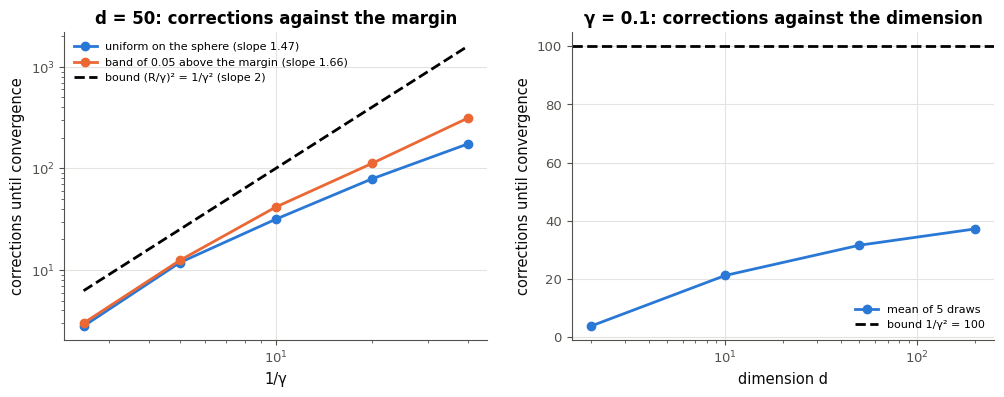

In [44]:
def margin_23(X, y, u):
    """Margin of the separator u on the data: min_i y_i u.x_i, with u made of norm 1 and the labels 0/1 coded -1/+1."""
    u = np.asarray(u, dtype=float)
    signs = np.where(np.asarray(y) == 1, 1.0, -1.0)
    return float(np.min(signs * (np.asarray(X, dtype=float) @ (u / np.linalg.norm(u)))))


def updates_23(X, y, seed):
    """Total number of corrections made by YOUR Perceptron without bias (fit_intercept=False), shuffled with
    random_state=seed, with at most 100 000 epochs: the sum of errors_."""
    model = mylearn.perceptron.Perceptron(fit_intercept=False, max_iter=100_000, shuffle=True, random_state=seed)
    return int(sum(model.fit(X, y).errors_))

if True:
    gamma_demo_23 = margin_23(X_demo_23, y_demo_23, 2 * np.eye(50)[0])     # u not of norm 1: margin_23 must normalise it
    if returned("10.23", "margin_23", gamma_demo_23):
        exact_23 = float(np.min(np.where(y_demo_23 == 1, 1, -1) * X_demo_23[:, 0]))
        verdict("10.23", np.isclose(float(gamma_demo_23), exact_23),
                f"marge mesurée sur les données de démonstration : {fr(float(gamma_demo_23), 4)} (au moins 0,1).",
                f"attendu {fr(exact_23, 4)} : le minimum de y_i u·x_i, avec u ramené à la norme 1 et des labels ±1.")
    X_probe_23, y_probe_23 = sphere_data_23(200, 0.1, 10, 0)               # a small separable set: (R/γ)² = 100
    small_23 = fitted(mylearn.perceptron.Perceptron(fit_intercept=False, max_iter=1000, shuffle=True, random_state=0),
                      X_probe_23, y_probe_23)
    errors_probe_23 = learned(small_23, "errors_")
    stops_23 = errors_probe_23 is not None and errors_probe_23[-1] == 0 and len(errors_probe_23) < 1000
    if not stops_23:
        print("❌ Ex 10.23 : ton Perceptron (10.21) ne s'arrête pas après la première époque sans erreur sur un petit "
              "jeu séparable (200 points, γ = 0,1) : corrige-le d'abord (ses tests, en 10.21), sinon les 50 "
              "perceptrons de l'expérience tourneraient pendant des heures.")
    probe_23 = updates_23(X_probe_23, y_probe_23, 0) if stops_23 else None
    if stops_23 and returned("10.23", "updates_23", probe_23):
        expected_23 = int(sum(errors_probe_23))
        verdict("10.23", int(probe_23) == expected_23,
                f"updates_23 compte les corrections de ton Perceptron : {expected_23} sur un petit jeu de contrôle.",
                f"sur un petit jeu de contrôle (200 points, γ = 0,1, dimension 10, graine 0), updates_23 renvoie "
                f"{probe_23}, alors que ton Perceptron sans biais, mélangé avec random_state=0, fait {expected_23} "
                "corrections (la somme de errors_) : vérifie fit_intercept=False, shuffle=True, random_state=seed et "
                "la somme.")
    if stops_23 and probe_23 is not None and int(probe_23) == int(sum(errors_probe_23)):
        start_23 = time.time()
        results_23, bound_ok_23 = {}, True
        for band_23 in (None, 0.05):
            for gamma_23 in GAMMAS_23:
                counts_23 = []
                for seed_23 in range(5):
                    X_23, y_23 = sphere_data_23(500, gamma_23, 50, seed_23, band_23)
                    counts_23.append(int(updates_23(X_23, y_23, seed_23)))
                    R_23 = np.max(np.linalg.norm(X_23, axis=1))
                    gamma_seen_23 = float(np.min(np.where(y_23 == 1, 1, -1) * X_23[:, 0]))   # margin of u = (1, 0, ..., 0)
                    bound_ok_23 &= counts_23[-1] <= (R_23 / gamma_seen_23) ** 2
                results_23[(band_23, gamma_23)] = counts_23
        print(f"{time.time() - start_23:.1f} s for 50 perceptrons (d = 50, n = 500, 5 draws per margin)")
        print(" gamma   bound 1/gamma²   mean updates (uniform)   mean updates (band of 0.05)")
        for gamma_23 in GAMMAS_23:
            print(f"{gamma_23:6.3f} {1 / gamma_23 ** 2:12g} {np.mean(results_23[(None, gamma_23)]):18.1f} "
                  f"{np.mean(results_23[(0.05, gamma_23)]):24.1f}")
        verdict("10.23", bool(bound_ok_23), "les 50 perceptrons respectent la borne (R/γ)², γ mesuré sur chaque tirage.",
                "un perceptron dépasse la borne (R/γ)² : vérifie updates_23 (sans biais, somme de errors_).")
        verdict("10.23", all(np.mean(results_23[(None, a)]) < np.mean(results_23[(None, b)])
                             for a, b in zip(GAMMAS_23, GAMMAS_23[1:])),
                "plus la marge est petite, plus il faut de corrections.",
                "le nombre moyen de corrections devrait croître quand la marge diminue : vérifie updates_23.")
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        inverse_23 = 1 / np.array(GAMMAS_23)
        for band_23, label_23 in [(None, "uniform on the sphere"), (0.05, "band of 0.05 above the margin")]:
            means_23 = [np.mean(results_23[(band_23, g)]) for g in GAMMAS_23]
            slope_23 = np.polyfit(np.log(inverse_23), np.log(means_23), 1)[0]
            axes[0].plot(inverse_23, means_23, "o-", label=f"{label_23} (slope {slope_23:.2f})")
        axes[0].plot(inverse_23, inverse_23 ** 2, "k--", label="bound (R/γ)² = 1/γ² (slope 2)")
        axes[0].set(xscale="log", yscale="log", xlabel="1/γ", ylabel="corrections until convergence",
                    title="d = 50: corrections against the margin")
        axes[0].legend(fontsize=8)
        dims_23 = [2, 10, 50, 200]
        by_dim_23 = [np.mean([updates_23(*sphere_data_23(500, 0.1, d, s), s) for s in range(5)]) for d in dims_23]
        print("gamma = 0.1, mean updates by dimension:", dict(zip(dims_23, np.round(by_dim_23, 1).tolist())), "· bound: 100")
        axes[1].plot(dims_23, by_dim_23, "o-", label="mean of 5 draws")
        axes[1].axhline(100, color="k", ls="--", label="bound 1/γ² = 100")
        axes[1].set(xscale="log", xlabel="dimension d", ylabel="corrections until convergence",
                    title="γ = 0.1: corrections against the dimension")
        axes[1].legend(fontsize=8)
        plt.show()

💡 Les 50 perceptrons restent sous la borne, et loin d'elle : en moyenne 2,8 corrections pour $\gamma = 0{,}4$ (borne 6,25), 31,6 pour $\gamma = 0{,}1$ (borne 100), 174 pour $\gamma = 0{,}025$ (borne 1 600). La pente des courbes vaut environ 1,5 (points uniformes) et 1,7 (points près de la marge), sous la pente 2 de la borne : la borne décrit le **pire** cas, que des données tirées au hasard n'atteignent pas ; elle s'en approche quand beaucoup de points sont près de la marge (313 corrections pour $\gamma = 0{,}025$, un cinquième de la borne, contre un neuvième). Chaque point proche de la frontière peut imposer sa correction ; des points loin d'elle sont classés presque d'office. La dimension : 3,8 corrections en dimension 2, 21 en dimension 10, 32 en 50 et 37 en 200, toujours sous la borne de 100, qui ne dépend pas de $d$. La raison de la hausse : sur la sphère de $\mathbb{R}^d$, la coordonnée $x_1$ d'un point tiré au hasard est de l'ordre de $1/\sqrt{d}$ ; en grande dimension, presque tous les points gardés sont donc juste au-dessus de la marge, comme avec `band`. La borne est utile pour **comprendre** (la marge gouverne la vitesse, pas la dimension ni le nombre d'exemples), rarement pour **prévoir** un nombre de corrections.

### Ex 10.24 — Trois espèces de manchots avec des perceptrons en un-contre-tous 🔬 ★★★ ⏱️ 35 min
**Objectif :** combiner des perceptrons binaires pour trois classes, et comprendre pourquoi un-contre-tous et un-contre-un ne voient pas les mêmes problèmes.  
**Prérequis :** Ex 10.21 · ch. 7 (un-contre-tous et un-contre-un, `multiclass.py`) · ch. 8 (découpage du ch. 1) · **Fil rouge :** Penguins · **Parcours :** C

Le perceptron ne sépare que deux classes. Tes méta-classifieurs du ch. 7, `mylearn.multiclass.OneVsRestClassifier` et `OneVsOneClassifier` (7.22, 7.23), savent en combiner plusieurs : ils copient un classifieur binaire non entraîné et l'entraînent sur chaque sous-problème. Avec **ton** `Perceptron(max_iter=100)` (10.21), écris :
- `ovr_24(X_train, y_train)` : un `OneVsRestClassifier` de perceptrons, entraîné ;
- `ovo_24(X_train, y_train)` : un `OneVsOneClassifier` de perceptrons, entraîné.

Les données : les quatre mesures des manchots, standardisées avec les 233 manchots d'entraînement du ch. 1 (`Z_peng_24`) ; on entraîne sur `TRAIN_CH1`, on teste sur `TEST_CH1`. La vérification affiche, pour chaque espèce, le nombre d'époques de son perceptron un-contre-tous et ses corrections à la dernière époque, puis contrôle :
a) l'accuracy de test du un-contre-tous ;
b) `not_converged_24` : les initiales (A, C, G) des espèces dont le perceptron « cette espèce contre les deux autres » n'a **pas** convergé en 100 époques sur les manchots d'entraînement (regarde les corrections de la dernière époque), par ordre alphabétique ;
c) l'accuracy de test du un-contre-un ;
et compare tes scores un-contre-tous à ceux du `Perceptron` multi-classe de scikit-learn.

Dans tes notes : un perceptron qui n'a pas convergé prouve-t-il que son problème n'est pas séparable (📈 10.19 f) ? Si « Adélie contre les deux autres » ne l'est vraiment pas, comment est-ce possible, alors que chaque paire d'espèces l'est (le un-contre-un converge sur les trois paires) ? Pourquoi le un-contre-un fait-il mieux ici ? Que fait scikit-learn quand on donne trois classes à son `Perceptron` ?

In [45]:
mean_24, std_24 = X_peng[TRAIN_CH1].mean(axis=0), X_peng[TRAIN_CH1].std(axis=0)
Z_peng_24 = (X_peng - mean_24) / std_24        # the 4 measurements, standardised with the 233 training penguins

In [46]:
def ovr_24(X_train, y_train):
    """One-versus-rest with YOUR perceptrons: a fitted mylearn.multiclass.OneVsRestClassifier(Perceptron(max_iter=100))."""
    return mylearn.multiclass.OneVsRestClassifier(mylearn.perceptron.Perceptron(max_iter=100)).fit(X_train, y_train)


def ovo_24(X_train, y_train):
    """One-versus-one with YOUR perceptrons: a fitted mylearn.multiclass.OneVsOneClassifier(Perceptron(max_iter=100))."""
    return mylearn.multiclass.OneVsOneClassifier(mylearn.perceptron.Perceptron(max_iter=100)).fit(X_train, y_train)


not_converged_24 = "AC"

print_answer("10.24b", not_converged_24)
if True:
    ovr_model_24 = ovr_24(Z_peng_24[TRAIN_CH1], species[TRAIN_CH1])
    if returned("10.24", "ovr_24", ovr_model_24):
        accuracy_ovr_24 = float(np.mean(ovr_model_24.predict(Z_peng_24[TEST_CH1]) == species[TEST_CH1]))
        print(f"one-versus-rest: test accuracy {accuracy_ovr_24:.2f}")
        for name_24, model_24 in zip(ovr_model_24.classes_, ovr_model_24.estimators_):
            errors_24 = learned(model_24, "errors_")
            if errors_24 is not None:
                print(f"   {name_24:9s} against the rest: {len(errors_24)} epochs, {errors_24[-1]} corrections in the last one")
        print_answer("10.24a", accuracy_ovr_24, computed=True)
        oracle_24 = SklearnPerceptron(max_iter=100, shuffle=False, tol=None).fit(Z_peng_24[TRAIN_CH1], species[TRAIN_CH1])
        verdict("10.24", np.allclose(ovr_model_24.decision_function(Z_peng_24[TEST_CH1]),
                                     oracle_24.decision_function(Z_peng_24[TEST_CH1])),
                "les trois scores de chaque manchot sont ceux du Perceptron multi-classe de scikit-learn : il fait du "
                "un-contre-tous.",
                "tes scores diffèrent de ceux du Perceptron multi-classe de scikit-learn (un-contre-tous, shuffle=False, "
                "tol=None) : vérifie ovr_24 et ton Perceptron (10.21).")
    ovo_model_24 = ovo_24(Z_peng_24[TRAIN_CH1], species[TRAIN_CH1])
    if returned("10.24", "ovo_24", ovo_model_24):
        predictions_ovo_24 = ovo_model_24.predict(Z_peng_24[TEST_CH1])
        accuracy_ovo_24 = float(np.mean(predictions_ovo_24 == species[TEST_CH1]))
        print(f"one-versus-one: test accuracy {accuracy_ovo_24:.2f}")
        for (first_24, second_24), model_24 in zip(ovo_model_24.pairs_, ovo_model_24.estimators_):
            errors_24 = learned(model_24, "errors_")
            if errors_24 is not None:
                print(f"   {ovo_model_24.classes_[first_24]} against {ovo_model_24.classes_[second_24]}: "
                      f"{len(errors_24)} epochs, {errors_24[-1]} corrections in the last one")
        print_answer("10.24c", accuracy_ovo_24, computed=True)
        wrong_24 = np.flatnonzero(predictions_ovo_24 != species[TEST_CH1])
        print("test penguins misclassified by one-versus-one:",
              [(species[TEST_CH1][i], predictions_ovo_24[i]) for i in wrong_24])

10.24b: AC
one-versus-rest: test accuracy 0.98
   Adelie    against the rest: 100 epochs, 5 corrections in the last one
   Chinstrap against the rest: 100 epochs, 10 corrections in the last one
   Gentoo    against the rest: 2 epochs, 0 corrections in the last one
10.24a: 0.98
✅ Ex 10.24 : les trois scores de chaque manchot sont ceux du Perceptron multi-classe de scikit-learn : il fait du un-contre-tous.
one-versus-one: test accuracy 0.99
   Adelie against Chinstrap: 32 epochs, 0 corrections in the last one
   Adelie against Gentoo: 2 epochs, 0 corrections in the last one
   Chinstrap against Gentoo: 2 epochs, 0 corrections in the last one
10.24c: 0.99
test penguins misclassified by one-versus-one: [('Adelie', 'Gentoo')]


In [47]:
wb.record("10.24a", accuracy_ovr_24, decimals=4, mistakes={"c'est l'accuracy du un-contre-un (question c)": accuracy_ovo_24})
wb.record("10.24b", not_converged_24, mistakes={"le perceptron « Gentoo contre le reste » converge en deux époques : c'est l'espèce la plus à part": "ACG",
                                                "regarde aussi les Chinstrap : leur perceptron fait encore des corrections à la 100e époque": "A",
                                                "regarde aussi les Adélie : leur perceptron fait encore des corrections à la 100e époque": "C"})
wb.record("10.24c", accuracy_ovo_24, decimals=4, mistakes={"c'est l'accuracy du un-contre-tous (question a)": accuracy_ovr_24})

WB_ANSWER {"decimals": 4, "hash": "b351dadd84309b01f3c540680f49167f6ff8e3ecbcf04d5a13f216d4a4362d74", "hash_coarse": "65b19e8cfecb9c027514109477ac541a490e1eb34e783d85872afe0eca872f0a", "id": "10.24a", "kind": "float", "magnitude": -1, "mistakes": {"54e08d66728fb7c154ccf4b344c03175bb436c076195f80615b15cbcbb3853a0": "c'est l'accuracy du un-contre-un (question c)"}, "sign": 1}
📝 Ex 10.24a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"hash": "8099baee06b2f0cd2a514cb565640edf518c6537f34841126a3a610d2b542f69", "id": "10.24b", "kind": "str", "mistakes": {"4ff0b9ad682a7f0af2c6826cc3ad57d929ad854b89b55439f46d6ea3f8d35280": "regarde aussi les Adélie : leur perceptron fait encore des corrections à la 100e époque", "7262692abbc6fde836000d6c8b177c3e04b6c1a1957214c874ee1bea9200a1ab": "le perceptron « Gentoo contre le reste » converge en deux époques : c'est l'espèce la plus à part", "e2e9041d449ec30d39fb8dc99209908815d79b3459fab1c143490831a2398ea2": "regarde aussi les Chinstrap : leur pe

💡 Le un-contre-tous fait 0,98 sur le test, le un-contre-un 0,99 (un seul manchot mal classé, une Adélie prise pour un Gentoo). Seul « Gentoo contre le reste » est séparable (2 époques) ; « Adélie contre le reste » et « Chinstrap contre le reste » font encore 5 et 10 corrections à la 100e époque (AC). Cela ne prouve rien à soi seul (📈 10.19 f), mais un programme linéaire le confirme : chercher $\mathbf{w}$ et $b$ tels que $y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \ge 1$ pour tout $i$ (`scipy.optimize.linprog`) n'a pas de solution pour ces deux problèmes, et en a une pour « Gentoo contre le reste ». Pourtant, chaque **paire** d'espèces est séparable : le un-contre-un converge sur les trois (32, 2 et 2 époques). Les deux frontières qui séparent les Adélie des Chinstrap et des Gentoo n'ont pas la même orientation : la première s'appuie surtout sur la longueur du bec, la seconde sur les quatre mesures à la fois. Sur ces données, aucun hyperplan ne fait les deux à la fois. Le un-contre-un garde trois frontières, une par paire, et leurs votes dessinent des régions qu'aucun hyperplan seul ne trace. Avec trois classes, le `Perceptron` de scikit-learn fait du un-contre-tous : ses scores sont exactement les tiens. Les perceptrons du un-contre-tous qui n'ont pas convergé gardent les poids de leur dernière époque, au hasard des dernières corrections : les scores comparés par l'argmax sont donc fragiles.

### Ex 10.25 — Défi « Mark I » : un perceptron sur des chiffres de 20 × 20 pixels 🏆 ★★★ ⏱️ 60 min
**Objectif :** construire, avec la seule règle du perceptron et une décision linéaire, un classifieur de chiffres manuscrits qui généralise, et le valider sans toucher au test.  
**Prérequis :** Ex 10.21 · ch. 8 (validation, règle du test unique) · fiche §10.3.2 (le Mark I, l'encadré 🧮 sur la convergence) · **Fil rouge :** MNIST · **Parcours :** C

Le Mark I lisait une image par 400 photocellules en carré de 20 × 20. Les chiffres de MNIST sont centrés dans des images de 28 × 28 pixels, et presque toute leur encre tient dans le carré central de 20 × 20. Ton défi : distinguer les **3** des **5** avec une seule unité linéaire, comme une unité de réponse du Mark I, entraînée sur **2 000 images** seulement.

1. Écris `crop_25(images)` : le carré central (lignes et colonnes 4 à 23) de chaque image de 28 × 28, en flottants entre 0 et 1, une ligne de 400 valeurs par image.
2. `ink_share_25` : la part de l'encre totale des 2 000 images d'entraînement (la somme des valeurs des pixels) qui tombe dans ce carré central.
3. Écris `train_mark1_25(X, y)`, qui reçoit les 400 photocellules d'images d'entraînement et leurs labels (3 ou 5), et renvoie `(w, b)` : la décision sera « 5 si $\mathbf{w}\cdot\mathbf{x} + b > 0$, 3 sinon ». Règles : la règle du perceptron et ce qu'on peut construire avec (ta classe `Perceptron` ou ta propre boucle), pas de régression logistique ni de SVM (ce sera au ch. 13) ; ta fonction n'utilise que les images qu'elle reçoit.

Le point de départ fourni prend les poids de ton `Perceptron(max_iter=100)` après la dernière époque. La vérification contrôle :
a) ta part de l'encre ;
b) l'accuracy du point de départ en validation croisée à 5 folds sur les 2 000 images d'entraînement ;
puis donne la validation croisée de **ta** méthode. Le test (les 1 902 images de 3 et de 5 du test de MNIST) n'est révélé qu'**une fois** par session, quand tu mets `READY_25 = True` ; ta méthode est alors aussi entraînée sur 4 autres tirages de 2 000 images d'entraînement, et évaluée sur les mêmes images de test.

**Objectif : une accuracy de test d'au moins 0,95, et d'au moins 0,945 en moyenne sur les 4 autres tirages.** Le point de départ n'y arrive pas. Pistes : la fiche (§10.3.2, encadré 🧮 sur la convergence) et l'encadré « Pour aller plus loin ».

Dans tes notes : ta méthode, son score en validation croisée, puis au test. Les 2 000 images sont-elles linéairement séparables, et qu'en disent les `errors_` du point de départ ? Pourquoi les poids de la **dernière** époque sont-ils un mauvais choix ici ? Pourquoi la validation croisée sur les 2 000 images suffit-elle pour choisir, sans regarder le test ?

In [48]:
X_mnist_25, y_mnist_25 = wb.datasets.load_mnist("train")              # 60 000 images 28 × 28, values 0 to 255
X_mnist_test_25, y_mnist_test_25 = wb.datasets.load_mnist("test")
PAIR_25 = (3, 5)                                                         # threes against fives
pool_25 = np.flatnonzero(np.isin(y_mnist_25, PAIR_25))                  # the 11 552 threes and fives for training
TRAIN_IDX_25 = np.random.default_rng(1025).choice(pool_25, 2000, replace=False)   # 2 000 images, a small machine
X_train_25, y_train_25 = X_mnist_25[TRAIN_IDX_25], y_mnist_25[TRAIN_IDX_25]
test_rows_25 = np.isin(y_mnist_test_25, PAIR_25)
X_test_25, y_test_25 = X_mnist_test_25[test_rows_25], y_mnist_test_25[test_rows_25]   # 1 902 test images
OTHER_DRAWS_25 = [np.random.default_rng(seed).choice(pool_25, 2000, replace=False) for seed in (2510, 3510, 4510, 5510)]
TEST_STATE_25 = {"test": None, "others": None}                           # the test is revealed once per session


def predict_25(w, b, X_photocells):
    """The decision of a linear unit on the 400 photocells: 5 where X @ w + b > 0, 3 elsewhere."""
    return np.where(np.asarray(X_photocells, dtype=float) @ w + b > 0, PAIR_25[1], PAIR_25[0])


def accuracy_of_25(train, X_img, y, X_eval_img, y_eval):
    """Train with train(crop_25(X_img), y) -> (w, b), then the accuracy on (X_eval_img, y_eval); or (None, reason)."""
    result = train(crop_25(X_img), y.copy())
    if not (isinstance(result, (tuple, list)) and len(result) == 2):
        return None, "train_mark1_25 doit renvoyer un couple (w, b)"
    w, b = np.asarray(result[0], dtype=float).ravel(), float(result[1])
    if w.shape != (400,):
        return None, f"w doit avoir 400 valeurs, une par photocellule, pas {w.size}"
    return float(np.mean(predict_25(w, b, crop_25(X_eval_img)) == y_eval)), ""


def cv_accuracy_25(train):
    """Mean accuracy of a 5-fold cross-validation of the method `train` on the 2 000 training images (no test)."""
    scores = []
    for tr, va in KFold(5, shuffle=True, random_state=25).split(X_train_25):
        score, reason = accuracy_of_25(train, X_train_25[tr], y_train_25[tr], X_train_25[va], y_train_25[va])
        if score is None:
            return None, reason
        scores.append(score)
    return float(np.mean(scores)), ""


def grade_25(train, reveal):
    """(result, reason): the cross-validated accuracy of your method; with reveal=True, its test accuracy (trained on
    the 2 000 images) and its mean test accuracy when trained on 4 other draws of 2 000 images, both computed at the
    first reveal of the session and kept."""
    cv, reason = cv_accuracy_25(train)
    if cv is None:
        return None, reason
    result = {"cv": cv, "test": None, "others": None}
    if not reveal:
        return result, "le test n'est pas encore révélé : mets READY_25 = True quand ta méthode est arrêtée"
    if TEST_STATE_25["test"] is None:
        TEST_STATE_25["test"] = accuracy_of_25(train, X_train_25, y_train_25, X_test_25, y_test_25)[0]
        TEST_STATE_25["others"] = float(np.mean([accuracy_of_25(train, X_mnist_25[idx], y_mnist_25[idx], X_test_25,
                                                                y_test_25)[0] for idx in OTHER_DRAWS_25]))
    else:
        print("⚠️ le test a déjà été révélé dans cette session : ta note reste celle de la première révélation.")
    result["test"], result["others"] = TEST_STATE_25["test"], TEST_STATE_25["others"]
    return result, ""


print("training images:", X_train_25.shape, dict(zip(*np.unique(y_train_25, return_counts=True))),
      "· test images:", X_test_25.shape)

training images: (2000, 28, 28) {np.int64(3): np.int64(1041), np.int64(5): np.int64(959)} · test images: (1902, 28, 28)


In [49]:
def crop_25(images):
    """The 400 "photocells" of the Mark I: the central 20 x 20 square (rows and columns 4 to 23) of each 28 x 28 image,
    as floats in [0, 1] (divide by 255), one row of 400 values per image."""
    images = np.asarray(images)
    return images[:, 4:24, 4:24].reshape(len(images), 400) / 255.0


ink_share_25 = float(X_train_25[:, 4:24, 4:24].sum(dtype=float) / X_train_25.sum(dtype=float))


def train_mark1_25(X, y):
    """Averaged perceptron: 10 shuffled epochs of the classic rule; return the mean of the weights after every sample."""
    classes = np.unique(y)
    target = np.where(y == classes[1], 1.0, -1.0)
    rng = np.random.default_rng(25)
    w, b = np.zeros(X.shape[1]), 0.0
    w_sum, b_sum, count = np.zeros(X.shape[1]), 0.0, 0
    for _ in range(10):
        for i in rng.permutation(len(X)):
            if target[i] * (X[i] @ w + b) <= 0:
                w = w + target[i] * X[i]
                b += target[i]
            w_sum += w
            b_sum += b
            count += 1
    return w_sum / count, b_sum / count


READY_25 = True

print_answer("10.25a", ink_share_25)
if True:
    cells_25 = crop_25(X_train_25[:3])
    if returned("10.25", "crop_25", cells_25):
        cells_25 = np.asarray(cells_25, dtype=float)
        verdict("10.25", cells_25.shape == (3, 400) and np.allclose(cells_25, X_train_25[:3, 4:24, 4:24].reshape(3, 400) / 255),
                "crop_25 : 400 photocellules par image, entre 0 et 1.",
                f"crop_25 doit renvoyer une ligne de 400 valeurs entre 0 et 1 par image ; reçu la forme {cells_25.shape}.")
        start_25 = time.time()
        baseline_25 = cv_accuracy_25(lambda X, y: (lambda m: (m.coef_, m.intercept_))(
            fitted(mylearn.perceptron.Perceptron(max_iter=100), X, y)))[0]
        print(f"starting point (your Perceptron, 100 epochs, in order): {baseline_25:.4f} in cross-validation "
              f"({time.time() - start_25:.0f} s)")
        print_answer("10.25b", baseline_25, computed=True)
        result_25, reason_25 = grade_25(train_mark1_25, READY_25)
        if result_25 is None:
            print(f"❌ Ex 10.25 : {reason_25}.")
        elif abs(result_25["cv"] - baseline_25) < 1e-12:
            print("⏳ Ex 10.25 : c'est encore le point de départ : à toi de faire mieux ; le test ne se révèle que pour "
                  "ta propre méthode.")
        else:
            print(f"your method: {result_25['cv']:.4f} in cross-validation on the 2 000 training images")
            if result_25["test"] is None:
                print(f"⏳ Ex 10.25 : {reason_25}.")
            else:
                print(f"test (1 902 images): {result_25['test']:.4f} · mean test accuracy when trained on 4 other "
                      f"draws of 2 000 images: {result_25['others']:.4f}")
                verdict("10.25", result_25["test"] >= 0.95, f"accuracy de test de {fr(result_25['test'], 4)} : objectif atteint.",
                        f"accuracy de test de {fr(result_25['test'], 4)} : il faut au moins 0,95.")
                verdict("10.25", result_25["others"] >= 0.945,
                        f"entraînée sur 4 autres tirages de 2 000 images, ta méthode tient sur le test (moyenne "
                        f"{fr(result_25['others'], 4)}).",
                        f"entraînée sur 4 autres tirages de 2 000 images, ta méthode n'obtient que "
                        f"{fr(result_25['others'], 4)} en moyenne sur le test : il faut au moins 0,945.")

10.25a: 0.9674061180006203
✅ Ex 10.25 : crop_25 : 400 photocellules par image, entre 0 et 1.


starting point (your Perceptron, 100 epochs, in order): 0.9300 in cross-validation (1 s)
10.25b: 0.93


your method: 0.9460 in cross-validation on the 2 000 training images
test (1 902 images): 0.9616 · mean test accuracy when trained on 4 other draws of 2 000 images: 0.9565
✅ Ex 10.25 : accuracy de test de 0,9616 : objectif atteint.
✅ Ex 10.25 : entraînée sur 4 autres tirages de 2 000 images, ta méthode tient sur le test (moyenne 0,9565).


In [50]:
wb.record("10.25a", ink_share_25, decimals=4, mistakes={"c'est la part des pixels du carré central (400 sur 784), pas la part de l'encre": 400 / 784})
wb.record("10.25b", baseline_25, decimals=4)

WB_ANSWER {"decimals": 4, "hash": "f22b841666b05eea7047a18c6ef06cdbce81434fb2a6ed9c3ec5a872ef7e43b4", "hash_coarse": "9315a76bb042b003c6efb6bac335ab4c19fd5f3245612a1823743f5e0bf1507a", "id": "10.25a", "kind": "float", "magnitude": -1, "mistakes": {"8f74fe581f693d41a30a6a6d1aae15eea1886f9a425f757f3fc82f97b0dcf8ac": "c'est la part des pixels du carré central (400 sur 784), pas la part de l'encre"}, "sign": 1}
📝 Ex 10.25a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "c7cfd95ef270cde3ceae693a2e36cabb849ac3792928bf23bba14fff8938ee51", "hash_coarse": "55f2aceda9465a64f7b2cae4ec785f05997d9552d367dc2267639cacae5ee68f", "id": "10.25b", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 10.25b : réponse enregistrée (float, 4 décimale(s)).


💡 La part de l'encre dans le carré central vaut 0,9674 : le recadrage ne perd que 3 % de l'encre, des bords de chiffres. Le point de départ fait 0,930 en validation croisée (0,944 au test, 0,927 en moyenne sur les quatre autres tirages). Les 2 000 images sont pourtant séparables (un programme linéaire le confirme, comme en 📈 10.19), mais avec une marge minuscule : dans l'ordre, le perceptron ne converge qu'à la 154e époque. Après 100 époques, il corrige encore une vingtaine d'images à chaque époque : les poids de la **dernière** époque dépendent des derniers exemples corrigés, et la frontière bouge encore d'une époque à l'autre. Même à la convergence, la frontière trouvée frôle des images d'entraînement et ne fait que 0,941 au test. Le corrigé est un perceptron **moyenné** (Freund et Schapire, 1999) : dix époques mélangées de la règle classique, et l'on renvoie la **moyenne** des poids après chaque exemple, ce qui lisse les oscillations : 0,946 en validation croisée, 0,962 au test, 0,956 en moyenne sur les autres tirages. L'algorithme « pocket » (Gallant, 1990), dans une version simple qui garde, sur dix époques mélangées, les poids de fin d'époque les plus justes sur l'entraînement, passe de justesse, et pas toujours : selon la graine du mélange (0 à 4), de 0,950 à 0,957 au test, mais une fois 0,9495. Un simple early stopping, avec un seul petit jeu de validation, ne suffit pas toujours : le choix du nombre d'époques est lui-même bruité. La validation croisée sur les 2 000 images permet de comparer ces méthodes sans regarder le test, qui ne sert qu'une fois, à la fin (ch. 8). Pour comparaison, une régression logistique, interdite ici, ferait 0,958 : le perceptron moyenné fait aussi bien que le classifieur linéaire « moderne » sur ce problème.

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu calculer à la main la sortie d'un perceptron, d'un neurone moderne et d'un petit réseau, et ranger ses poids dans une matrice ?
2. Sais-tu programmer et vérifier la règle d'apprentissage du perceptron, et dire quand elle converge ?
3. Sais-tu expliquer pourquoi un perceptron ne calcule pas XOR, et comment on dépasse cette limite ?

**Pour aller plus loin** : le chapitre « The Perceptron » du livre libre de H. Daumé III, *A Course in Machine Learning*, cité dans la fiche. La suite : le ch. 11 (apprentissage et raisonnement), où le livre revient sur l'entraînement du perceptron, puis le ch. 13, où le SVM cherche la frontière de **plus grande marge**, et les ch. 16 à 18, où les neurones s'assemblent en réseaux.